# PM2.5 Forecasting using Gaussian Process Regression (GPR)

This notebook demonstrates a full pipeline for PM2.5 time series forecasting using Gaussian Process Regression (GPR).

## Objectives
- Preprocess PM2.5 data
- Apply smoothing techniques
- Build and train Gaussian Process models
- Generate forecasts
- Evaluate model performance using statistical metrics

---


# PM2.5 Forecasting using Gaussian Process Regression

This notebook provides a clean and minimal pipeline for PM2.5 forecasting using Gaussian Process Regression (GPflow).

## Workflow
1. Import libraries  
2. Load dataset  
3. Preprocess data  
4. Train GP model  
5. Make predictions  
6. Evaluate performance  

All instructions and comments are written in English for public sharing.


## Requirements

- Python 3.9+
- numpy
- pandas
- matplotlib
- gpflow
- tensorflow

Install dependencies:

```bash
pip install numpy pandas matplotlib gpflow tensorflow

## Modelling Note

The Gaussian Process model can include multiple components:
- Long-term trend (e.g., Matern kernel)
- Sub-daily periodicity
- Daily periodicity

These components help capture different temporal patterns in PM2.5 data.

## Step 1: Import Libraries

We begin by importing all required Python libraries:
- `numpy`, `pandas`: data handling
- `matplotlib`: visualization
- `gpflow`, `tensorflow`: Gaussian Process modeling
- Other utilities for preprocessing and evaluation


In [9]:
import sys
print(sys.executable)

c:\ProgramData\anaconda3\envs\gpflow_env\python.exe


In [10]:
# =========================
# 1. Import Libraries
# =========================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import gpflow
from gpflow.utilities import print_summary

def to_float64(X):
    """
    Convert input data to float64.

    GPflow requires input data to be in float64 format.
    This function ensures compatibility and prevents dtype errors.
    """
    return np.asarray(X, dtype=np.float64)

## Step 2: Load and Prepare Data

In this step:
- Load PM2.5 dataset
- Convert timestamps
- Filter data by sensor and year
- Resample to uniform intervals
- Generate a complete time index

In [8]:
# =========================
# 2.1 Load dataset
# =========================
PMdata2018 = pd.read_csv("2018-PM25.csv")

PMdata2018['Timestamp'] = pd.to_datetime(PMdata2018['Timestamp'])
PMdata2018 = PMdata2018.sort_values('Timestamp')

PMdata2018.head()


,Sensor Name,Variable,Units,Timestamp,Value,Location (WKT),Ground Height Above Sea Level,Sensor Height Above Ground,Broker Name,Sensor Centroid Longitude,Sensor Centroid Latitude,Raw ID
0,PER_AIRMON_MESH1757150,PM2.5,ugm -3,2018-01-01 00:00:00,7.1830,POINT(-1.61731 54.97226),45.369999,2.0,aq_mesh_api,-1.617310,54.972260,73086
15,PER_AIRMON_MESH1756150,PM2.5,ugm -3,2018-01-01 00:15:00,7.0346,POINT(-1.617166 54.974211),47.369999,2.0,aq_mesh_api,-1.617166,54.974211,73085
14,PER_AIRMON_MESH1762150,PM2.5,ugm -3,2018-01-01 00:15:00,6.2401,POINT(-1.61096 54.973188),40.849998,2.0,aq_mesh_api,-1.610960,54.973188,73091
13,PER_AIRMON_MESH1764150,PM2.5,ugm -3,2018-01-01 00:15:00,5.1319,POINT(-1.6135 54.97768),47.599998,2.0,aq_mesh_api,-1.613500,54.977680,73093
12,PER_AIRMON_MESH1909150,PM2.5,ugm -3,2018-01-01 00:15:00,4.7856,POINT(-1.603448 54.965685),31.170000,2.0,aq_mesh_api,-1.603448,54.965685,79152


In [11]:
# =========================
# 2.2 Filter and Resample
# =========================
"""
Filter and resample PM2.5 data for a specific sensor and year.

Steps:
1. Convert timestamp to datetime format
2. Filter dataset by sensor name
3. Restrict data to a specific year
4. Resample to uniform 15-minute intervals
5. Preserve missing values (no interpolation)

Why this step is important:
- Ensures consistent temporal resolution
- Removes irregular sampling issues
- Enables reliable rolling statistics
- Missing values are intentionally preserved to avoid introducing artificial bias
"""
def filter_and_resample_data(sensor_name, data, year):
    """
    Filters PM2.5 data for a specific sensor and year,
    then resamples it to uniform 15-minute intervals.

    Parameters:
    - sensor_name (str): Target sensor ID
    - data (DataFrame): Raw dataset
    - year (int): Target year

    Returns:
    - DataFrame: Cleaned and resampled dataset
    """

    # --- Convert timestamp ---
    data["Timestamp"] = pd.to_datetime(data["Timestamp"], errors="coerce")

    # --- Filter by sensor ---
    sensor_data = data[data["Sensor Name"] == sensor_name].copy()

    # --- Define yearly range ---
    start_date = f"{year}-01-01 00:00:00"
    end_date   = f"{year}-12-31 23:59:59"

    # --- Filter by date ---
    filtered_data = sensor_data.loc[
        (sensor_data["Timestamp"] >= start_date) &
        (sensor_data["Timestamp"] <= end_date)
    ]

    # --- Set index for resampling ---
    filtered_data = filtered_data.set_index("Timestamp")

    # --- Resample to 15-minute intervals (no filling) ---
    # 15-minute resolution balances temporal detail and computational cost
    resampled_data = filtered_data.resample("15T").asfreq()

    # --- Reset index ---
    resampled_data = resampled_data.reset_index()

    return resampled_data

In [12]:
# =========================
# 2.3 Apply Filtering
# =========================

sensor_name01 = "PER_AIRMON_MESH1759150"

PM25_2018_sensor001 = filter_and_resample_data(
    sensor_name01,
    PMdata2018,
    2018
)
pm25_sensor1 = PM25_2018_sensor001.copy()

C:\Users\c3040922\AppData\Local\Temp\ipykernel_27908\302904286.py:55: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  resampled_data = filtered_data.resample("15T").asfreq()


In [ ]:
# =========================
# 2.4 Time Index Generation
# =========================

"""
Create a complete time index for the entire year
with 15-minute resolution.

Useful for:
- Detecting missing timestamps
- Aligning predictions
"""

start_date = "2018-01-01 00:00:00"
end_date   = "2018-12-31 23:59:00"

time_wholeyear_pm = pd.date_range(
    start=start_date,
    end=end_date,
    freq="15min"
)

## Step 3: Data Preprocessing

Key preprocessing steps:
- Apply smoothing (e.g., rolling mean)
- Normalize or scale data if required
- Prepare training and testing windows


In [ ]:
# =========================
# Data Preprocessing
# =========================

"""
Preprocess PM2.5 dataset and generate rolling statistics.

Steps:
1. Ensure datetime format
2. Sort data chronologically
3. Compute short-term smoothing
4. Estimate long-term trend (~1 day)
5. Detrend signal
6. Smooth detrended signal

Why preprocessing is important:
- Reduces high-frequency noise in PM2.5 observations
- Separates long-term trends from short-term fluctuations
- Improves Gaussian Process model stability and predictive performance

Notes:
- 15-minute interval data
- 96 points ≈ 1 day → use 97 (centered window)
"""

# --- Ensure datetime format ---
pm25_sensor1["Timestamp"] = pd.to_datetime(pm25_sensor1["Timestamp"], errors="coerce")

# --- Sort data ---
pm25_sensor1 = pm25_sensor1.sort_values("Timestamp").reset_index(drop=True)

# --- Set index for rolling operations ---
pm25_sensor1 = pm25_sensor1.set_index("Timestamp")


# =========================
# Rolling Statistics (Short-term)
# =========================

"""
Short-term smoothing (noise reduction)
Window = 5 points ≈ 75 minutes
"""

# Short-term smoothing reduces high-frequency noise
# Window = 5 (~75 minutes) captures local variations without over-smoothing

pm25_sensor1["Rolling Mean"] = pm25_sensor1["Value"].rolling(
    window=5, min_periods=1, center=True
).mean()

pm25_sensor1["Rolling Std"] = pm25_sensor1["Value"].rolling(
    window=5, min_periods=1, center=True
).std()

pm25_sensor1["Rolling Median"] = pm25_sensor1["Value"].rolling(
    window=5, min_periods=1, center=True
).median()


# =========================
# Long-term Trend (Detrending)
# =========================

"""
Estimate daily trend using rolling mean
97 points ≈ 24 hours (centered window)

A daily window is used to capture diurnal patterns
commonly observed in PM2.5 concentrations.
"""

pm25_sensor1["Rolling Mean (1D)"] = pm25_sensor1["Value"].rolling(
    window=97, min_periods=1, center=True
).mean()

# Remove long-term trend to isolate short-term variability
pm25_sensor1["Detrended"] = pm25_sensor1["Value"] - pm25_sensor1["Rolling Mean (1D)"]


# =========================
# Smoothed Detrended Signal
# =========================

"""
Apply smoothing to detrended signal

This step further reduces residual noise
and improves signal quality for GP modeling.
"""

pm25_sensor1["Rolling Detrended"] = pm25_sensor1["Detrended"].rolling(
    window=5, min_periods=1, center=True
).mean()


# =========================
# Reset index
# =========================

pm25_sensor1 = pm25_sensor1.reset_index()

# Use both raw and smoothed data for comparison
# Raw data preserves original signal
# Smoothed data improves model robustness
PM25_data = pm25_sensor1['Value']
Smooth_PM25 = pm25_sensor1['Rolling Mean']

print("Data prepared for GP model")

# =========================
# Output check
# =========================

print("Preprocessing completed.")
print(pm25_sensor1[["Timestamp", "Value", "Rolling Mean", "Rolling Mean (1D)", "Detrended"]].head())

Data prepared for GP model
Preprocessing completed.
            Timestamp   Value  Rolling Mean  Rolling Mean (1D)  Detrended
0 2018-01-01 00:15:00  6.4107      4.476433           2.364771   4.045929
1 2018-01-01 00:30:00  4.4283      4.026825           2.387664   2.040636
2 2018-01-01 00:45:00  2.5903      3.656240           2.425986   0.164314
3 2018-01-01 01:00:00  2.6780      2.826620           2.449910   0.228090
4 2018-01-01 01:15:00  2.1739      2.274600           2.473053  -0.299153


In [ ]:
pm25_sensor1.head()

,Timestamp,Sensor Name,Variable,Units,Value,Location (WKT),Ground Height Above Sea Level,Sensor Height Above Ground,Broker Name,Sensor Centroid Longitude,Sensor Centroid Latitude,Raw ID,Rolling Mean,Rolling Std,Rolling Median,Rolling Mean (1D),Detrended,Rolling Detrended
0,2018-01-01 00:15:00,PER_AIRMON_MESH1759150,PM2.5,ugm -3,6.4107,POINT(-1.613355 54.977854),47.779999,2.0,aq_mesh_api,-1.613355,54.977854,73088.0,4.476433,1.910655,4.42830,2.364771,4.045929,2.083626
1,2018-01-01 00:30:00,PER_AIRMON_MESH1759150,PM2.5,ugm -3,4.4283,POINT(-1.613355 54.977854),47.779999,2.0,aq_mesh_api,-1.613355,54.977854,73088.0,4.026825,1.800646,3.55315,2.387664,2.040636,1.619742
2,2018-01-01 00:45:00,PER_AIRMON_MESH1759150,PM2.5,ugm -3,2.5903,POINT(-1.613355 54.977854),47.779999,2.0,aq_mesh_api,-1.613355,54.977854,73088.0,3.656240,1.765902,2.67800,2.425986,0.164314,1.235963
3,2018-01-01 01:00:00,PER_AIRMON_MESH1759150,PM2.5,ugm -3,2.6780,POINT(-1.613355 54.977854),47.779999,2.0,aq_mesh_api,-1.613355,54.977854,73088.0,2.826620,0.920255,2.59030,2.449910,0.228090,0.376840
4,2018-01-01 01:15:00,PER_AIRMON_MESH1759150,PM2.5,ugm -3,2.1739,POINT(-1.613355 54.977854),47.779999,2.0,aq_mesh_api,-1.613355,54.977854,73088.0,2.274600,0.400126,2.26260,2.473053,-0.299153,-0.209244


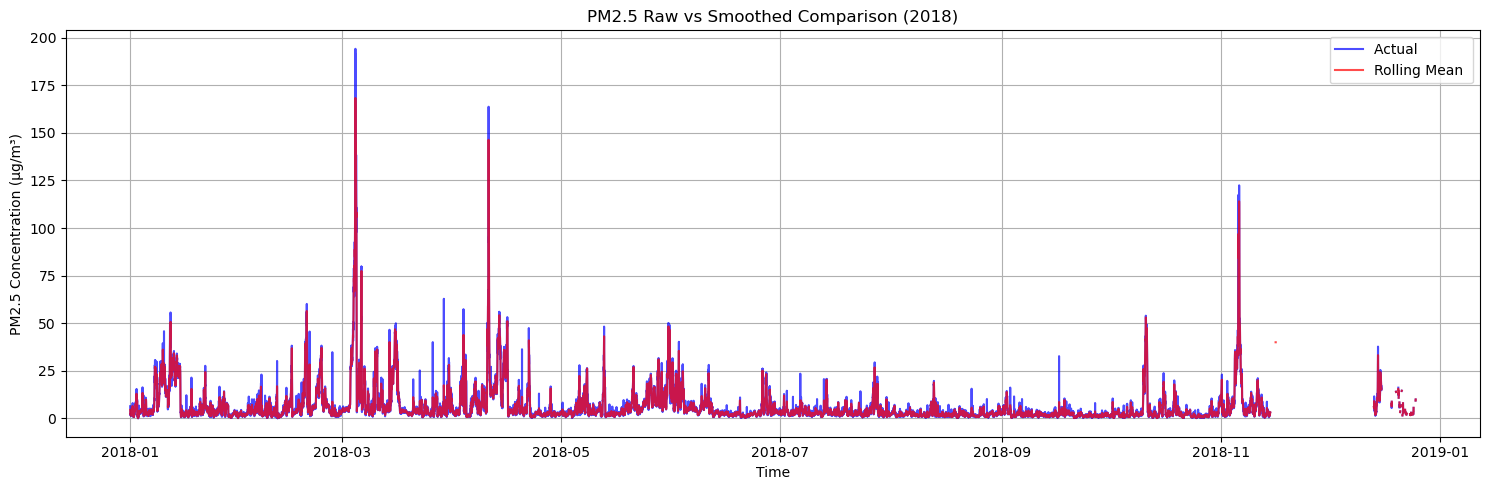

In [ ]:
plt.figure(figsize=(15, 5))

# Plot sensor 1
plt.plot(pm25_sensor1['Timestamp'], pm25_sensor1['Value'], 
         label='Actual ' , color='blue', alpha=0.7)

# Plot sensor 2
plt.plot(pm25_sensor1['Timestamp'], pm25_sensor1['Rolling Mean'], 
         label='Rolling Mean ' , color='red', alpha=0.7)

plt.xlabel('Time')
plt.ylabel('PM2.5 Concentration (µg/m³)')
plt.title('PM2.5 Raw vs Smoothed Comparison (2018)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## Step 5: Model Training

- Initialize Gaussian Process model
- Optimize kernel hyperparameters
- Monitor convergence behavior


## Step 6: Prediction

- Generate forecasts for the test window
- Extract mean and variance predictions


## Step 4: Evaluation Metrics

In this step, we evaluate the performance of the Gaussian Process model 
using multiple statistical metrics.

These metrics assess different aspects of prediction quality:

- **RMSE (Root Mean Square Error)**: measures overall prediction error magnitude  
- **MAE (Mean Absolute Error)**: measures average absolute deviation  
- **R² (Coefficient of Determination)**: measures goodness of fit  
- **IOA (Index of Agreement)**: measures agreement between prediction and observation  
- **MAPE (Mean Absolute Percentage Error)**: measures relative error (%)  
- **NMB (Normalized Mean Bias)**: indicates systematic bias  
- **FAC2 (Factor of 2)**: fraction of predictions within a factor of 2  
- **FB (Fractional Bias)**: normalized bias measure  

Using multiple metrics ensures a comprehensive evaluation of model accuracy, 
bias, and robustness.

### Why multiple metrics?

No single metric can fully describe model performance.

- Error-based metrics (RMSE, MAE) quantify magnitude of errors  
- Correlation-based metrics (R²) assess trend agreement  
- Bias metrics (NMB, FB) detect systematic over/underestimation  
- Agreement metrics (IOA, FAC2) evaluate predictive reliability  

This combination provides a robust and reliable evaluation framework 
for PM2.5 forecasting models.

In [ ]:
# =========================
# 4. Evaluation Functions
# =========================

import numpy as np
from sklearn.metrics import mean_squared_error, mean_squared_log_error, r2_score

def calculate_metrics(y_true_train, y_pred_train, y_true_test, y_pred_test):
    """
    Compute evaluation metrics for training and testing datasets.

    Steps:
    1. Remove NaN values
    2. Compute error-based metrics
    3. Compute bias and agreement metrics

    Returns:
    - Dictionary of evaluation metrics
    """

    # --- Remove NaNs ---
    mask_train = ~ (np.isnan(y_true_train) | np.isnan(y_pred_train))
    mask_test  = ~ (np.isnan(y_true_test)  | np.isnan(y_pred_test))

    y_true_train = y_true_train[mask_train]
    y_pred_train = y_pred_train[mask_train]
    y_true = y_true_test[mask_test]
    y_pred = y_pred_test[mask_test]

    # --- MSE / RMSE ---
    mse_train = mean_squared_error(y_true_train, y_pred_train)
    mse = mean_squared_error(y_true, y_pred)

    rmse_train = np.sqrt(mse_train)
    rmse = np.sqrt(mse)

    # --- RMSLE ---
    rmsle = np.sqrt(mean_squared_log_error(y_true, y_pred))

    # --- Bias metrics ---
    nmb = np.sum(y_pred - y_true) / np.sum(y_true)
    fb  = 2 * (np.mean(y_pred) - np.mean(y_true)) / (np.mean(y_pred) + np.mean(y_true))

    # --- Percentage error ---
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100

    # --- Agreement ---
    y_bar = np.mean(y_true)
    ioa = 1 - (
        np.sum((y_true - y_pred)**2) /
        np.sum((np.abs(y_pred - y_bar) + np.abs(y_true - y_bar))**2)
    )

    # --- R² ---
    r2 = r2_score(y_true, y_pred)

    # --- FAC2 ---
    fac2 = np.mean((y_pred / y_true >= 0.5) & (y_pred / y_true <= 2))

    # --- Relative RMSE ---
    rRMSE = rmse / rmse_train

    return {
        "RMSE_train": rmse_train,
        "RMSE_test": rmse,
        "RMSLE": rmsle,
        "NMB": nmb,
        "MAPE": mape,
        "IOA": ioa,
        "R2": r2,
        "FAC2": fac2,
        "FB": fb,
        "rRMSE": rRMSE
    }

In [ ]:
# Example data
y_true = np.array([16.17, 17.10, 15.08, 15.15, 13.90])
y_pred = np.array([17.15, 16.85, 16.49, 15.82, 15.02])
y_sld1 = np.array([16.44, 16.12, 15.88, 15.31, 14.35])

# Compute metrics
metrics_pred = calculate_metrics(y_true, y_pred, y_true, y_pred)
metrics_sld1 = calculate_metrics(y_true, y_sld1, y_true, y_sld1)

# Display
print("Prediction Metrics:")
for k, v in metrics_pred.items():
    print(f"{k}: {v:.3f}")

Prediction Metrics:
RMSE_train: 0.971
RMSE_test: 0.971
RMSLE: 0.059
NMB: 0.051
MAPE: 5.871
IOA: 0.777
R2: 0.196
FAC2: 1.000
FB: 0.050
rRMSE: 1.000


In [ ]:
# Helper metrics
import numpy as np
from sklearn.metrics import mean_squared_error, mean_squared_log_error, r2_score

# Define the metrics calculation
def calculate_metrics(y_true0_train,y_pred0_train,y_true0, y_pred0):
    # Step 1: Find indices where either array1 or array2 has NaN values
    nan_mask0 = np.isnan(y_true0_train) | np.isnan(y_pred0_train)
    nan_mask = np.isnan(y_true0) | np.isnan(y_pred0)

    # Step 2: Remove rows where NaN values are present in either array
    y_true_train = y_true0_train[~nan_mask0]
    y_pred_train = y_pred0_train[~nan_mask0]
    y_true = y_true0[~nan_mask]
    y_pred = y_pred0[~nan_mask]
    
    # Mean Squared Error (MSE)
    mse_train = mean_squared_error(y_true_train, y_pred_train)
    
    mse = mean_squared_error(y_true, y_pred)
    
    # Root Mean Squared Error (RMSE)
    rmse_train = np.sqrt(mse_train)
    rmse = np.sqrt(mse)
    
    
    # Root Mean Squared Logarithmic Error (RMSLE)
    rmsle = np.sqrt(mean_squared_log_error(y_true, y_pred))
    
    # Normalized Mean Bias (NMB)
    nmb = np.sum(y_pred - y_true) / np.sum(y_true)
    
    # Mean Absolute Percentage Error (MAPE)
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    
    # Index of Agreement (IOA)
    y_bar = np.mean(y_true)
    ioa = 1 - (np.sum((y_true - y_pred)**2) / np.sum((np.abs(y_pred - y_bar) + np.abs(y_true - y_bar))**2))
    
    # Coefficient of Determination (R²)
    r2 = r2_score(y_true, y_pred)
    
    #factor of 2 (FAC2)
    fac2 = np.mean((y_pred / y_true >= 0.5) & (y_pred / y_true <= 2))
    
    #Factional bias
    
    fb= 2 * (np.mean(y_pred) - np.mean(y_true)) / (np.mean(y_pred) + np.mean(y_true))
    
    #Ration of RMSE
    rRMSE = rmse/rmse_train
    
    return mse, rmse_train,rmse, rmsle, nmb, mape, ioa, r2, fac2,fb,rRMSE

# Example y_true, y_pred, y_sld1 data (use your actual data)
y_true = np.array([16.174801, 17.109400, 15.086500, 15.156400, 13.903300])
y_pred = np.array([17.153902, 16.852343, 16.491993, 15.828706, 15.024144])
y_sld1 = np.array([16.442633, 16.123567, 15.881775, 15.319090, 14.350175])

# Calculate metrics for true vs predicted values
metrics_pred = calculate_metrics(y_true, y_pred,y_true, y_pred)

# Calculate metrics for true vs smoothed (sld1) values
metrics_sld1 = calculate_metrics(y_true, y_sld1,y_true, y_pred)

# Display results
# print("Metric      True Values  Smoothed Values (sld1)")
# print(f"MSE        {metrics_pred[0]:.2f}        {metrics_sld1[0]:.2f}")
# print(f"RMSE Train {metrics_pred[1]:.2f}        {metrics_sld1[1]:.2f}")
# print(f"RMSE Test  {metrics_pred[2]:.2f}        {metrics_sld1[2]:.2f}")
# print(f"RMSLE      {metrics_pred[3]:.2f}        {metrics_sld1[3]:.2f}")
# print(f"NMB        {metrics_pred[4]:.2f}        {metrics_sld1[4]:.2f}")
# print(f"MAPE       {metrics_pred[5]:.2f}        {metrics_sld1[5]:.2f}")
# print(f"IOA        {metrics_pred[6]:.2f}        {metrics_sld1[6]:.2f}")
# print(f"R²         {metrics_pred[7]:.2f}        {metrics_sld1[7]:.2f}")

# print(f"fac2       {metrics_pred[8]:.2f}        {metrics_sld1[8]:.2f}")

# print(f"fb         {metrics_pred[9]:.2f}        {metrics_sld1[9]:.2f}")

# print(f"Ration RMSE{metrics_pred[10]:.2f}        {metrics_sld1[10]:.2f}")


## Step 5: Kernel Design

In this step, we construct a composite kernel for the Gaussian Process model 
to capture multiple temporal structures in PM2.5 data.

The kernel is designed as an additive combination of components:

- **Matérn 3/2 kernel**: captures smooth long-term trends  
- **Sub-daily periodic kernel**: captures intra-day variability (e.g., traffic, human activity)  
- **Daily periodic kernel**: captures diurnal cycles (24-hour pattern)  

This decomposition allows the model to represent complex temporal dynamics 
in a flexible and interpretable manner.

### Why composite kernels?

PM2.5 time series exhibit multiple temporal patterns:

- Long-term variations (meteorological effects, seasonal changes)  
- Sub-daily fluctuations (rush hours, industrial activity)  
- Daily cycles (diurnal atmospheric processes)  

A single kernel cannot capture all these patterns effectively.

By combining multiple kernels, the Gaussian Process can:
- Model each temporal scale separately  
- Improve predictive accuracy  
- Enhance interpretability of model components  

### Kernel Structure

The final kernel can be expressed as:

k(x, x') = k_trend + k_subdaily + k_daily

where:
- k_trend: Matérn 3/2 kernel  
- k_subdaily: Periodic kernel with flexible period (learned)  
- k_daily: Periodic kernel with fixed period (1440 minutes = 24 hours)  

### Design Considerations

- The daily period is fixed at 1440 minutes to enforce a 24-hour cycle  
- Sub-daily periodicity is learned from data to capture shorter cycles  
- Random initialization (log-normal sampling) improves robustness against local optima  
- Optional priors can guide kernel parameter estimation  

This design ensures both flexibility and stability in model training.

In [ ]:
"""
GP Prediction, Visualization, and Evaluation Utilities

Description:
Complete module for:
- Data preparation
- Transformation (log / square)
- GP prediction (train + forecast)
- Confidence intervals (80%, 95%)
- Deterministic + probabilistic metrics (CRPS)
- AQI visualization (UK scale)
- Optional diagnostics (Bastos & O'Hagan)

"""

import os
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import gpflow
from datetime import datetime, timedelta
from properscoring import crps_gaussian


# =========================================================
# 5.1 Utility Functions
# =========================================================

def ensure_numpy_1d(x):
    """Convert TensorFlow / array-like → 1D numpy array."""
    if hasattr(x, "numpy"):
        x = x.numpy()
    return np.ravel(x)

def as1d(a):
    """Return a 1-D numpy array regardless of TF/np shape."""
    if hasattr(a, "numpy"):
        a = a.numpy()
    a = np.asarray(a)
    return np.ravel(a)

def as2d_col(x):
    """Convert to (N,1) shape for GP input."""
    return ensure_numpy_1d(x).reshape(-1, 1)


def sanitize_filename(name):
    """Safe filename."""
    return name.replace("/", "-").replace(":", "-").replace(" ", "_")


def prepare_data(X, Y):
    """Remove NaNs and reshape."""
    mask = ~np.isnan(Y)
    return X[mask][:, None].astype(np.float64), Y[mask][:, None].astype(np.float64)

# Prevent unrealistic long periods that may destabilize the model
def enforce_max_period(kernel, max_period=1440.0):
    for subkernel in kernel.kernels:
        if isinstance(subkernel, gpflow.kernels.Periodic):
            current_period = subkernel.period.numpy()
            if current_period > max_period:
                print(f"⚠️ Period {current_period:.2f} exceeds {max_period}, clipping.")
                subkernel.period.assign(max_period)
# =========================================================
# 5.2 Transformations
# =========================================================

def transform_y(Y, method):
    """Forward transform."""
    if method == "actual":
        return Y
    elif method == "square":
        return np.square(Y)
    elif method == "ln":
        return np.log(Y + 1)
    else:
        raise ValueError("Invalid transform")


def inverse_transform(y, method):
    """Inverse transform."""
    y = ensure_numpy_1d(y)

    if method == "actual":
        return y
    elif method == "square":
        return np.sqrt(np.maximum(y, 0))
    elif method == "ln":
        return np.exp(y) - 1
    else:
        raise ValueError("Invalid transform")


# =========================================================
# 5.3 Confidence Intervals
# =========================================================

def compute_confidence_intervals(mean, variance):
    """Compute 95% and 80% confidence intervals."""
    std_dev = np.sqrt(np.clip(variance, 1e-12, None))
    
    # Ensure mean and std_dev are handled as numpy for consistent slicing
    mean_np = ensure_numpy_1d(mean)
    std_np = ensure_numpy_1d(std_dev)
    
    lower_95, upper_95 = mean_np - 1.96 * std_np, mean_np + 1.96 * std_np
    lower_80, upper_80 = mean_np - 1.28 * std_np, mean_np + 1.28 * std_np
    
    return {
        "95%": (lower_95, upper_95),
        "80%": (lower_80, upper_80),
    }
# =========================================================
# 5.4 Main Function
# =========================================================
def plot_prediction_method(
    model, 
    X, 
    Y,
    Y_sld1_ori, 
    min_x, 
    max_x, 
    t, 
    st_date, 
    method, 
    name, 
    name2, 
    pic_name, 
    kernel_type, 
    save_opt, 
    diagnostics=False
):
    """Generate GP predictions, plot results, and run diagnostics without redundancy.""" 
    gap = (max_x - len(X)) * 15
    delta = 15
    start_idx = len(X)
    
    # 1. Setup Time Ranges
    X_train_raw = np.arange(min_x, (max_x + 1) * 15 - gap, delta)[:, None].astype(np.float64)
    X_test_raw = np.arange(max_x * 15 - gap, max_x * 15, delta)[:, None].astype(np.float64)
    X_full_raw = np.arange(min_x, max_x * 15, delta)[:, None].astype(np.float64)

    # 2. Get Model Predictions
    # predict_y includes likelihood noise, predict_f is for latent function (diagnostics)
    f_mean_train, f_var_train = model.predict_y(X_train_raw)
    y_mean_test, y_cov_test = model.predict_y(X_test_raw)
    # --- Confidence intervals (pointwise/diagonal) ---
    conf_train = compute_confidence_intervals(f_mean_train, f_var_train)
    conf_ytest = compute_confidence_intervals(y_mean_test, y_cov_test)

    # 3. Inverse Transform Function
    def inv_t(val):
        if method == "ln": return np.exp(val) - 1
        if method == "square": return np.sqrt(val) # Assuming input was Y^2
        return val
    # convert to numpy arrays for downstream (1D vectors)
    f_mean_train_np = inv_t(as1d(f_mean_train))
    y_mean_test_np  = inv_t(as1d(y_mean_test))

    # apply inverse transform to CI bounds
    def inv_bounds(bounds):
        lo, hi = bounds
        return inv_t(as1d(lo)), inv_t(as1d(hi))

    conf_train = {"95%": inv_bounds(conf_train["95%"]), "80%": inv_bounds(conf_train["80%"])}
    conf_ytest = {"95%": inv_bounds(conf_ytest["95%"]), "80%": inv_bounds(conf_ytest["80%"])}

    # clip lower bounds at 0 for PM2.5
    for k in ("95%", "80%"):
        lo_t, hi_t = conf_train[k]
        lo_s, hi_s = conf_ytest[k]
        conf_train[k] = (np.clip(lo_t, 0, None), hi_t)
        conf_ytest[k] = (np.clip(lo_s, 0, None), hi_s)

    # --- Prepare arrays for plotting & metrics ---
    X_full_r, X_test_r, X_train_r = map(np.ravel, (X_full_raw, X_test_raw, X_train_raw))
    # Transform everything to original scale for plotting and metrics
    Y_plot = inv_t(Y)
    Y_sld_plot = inv_t(Y_sld1_ori)
    mu_tr_plot = inv_t(ensure_numpy_1d(f_mean_train))
    mu_te_plot = inv_t(ensure_numpy_1d(y_mean_test))
    
    Y_test       = Y_plot[start_idx:]
    Y_sld_mean1h = Y_sld_plot[start_idx:]
    

    # Compute CIs on transformed scale, then inverse transform
    ci_tr = compute_confidence_intervals(f_mean_train, f_var_train)
    ci_te = compute_confidence_intervals(y_mean_test, y_cov_test)
    
    tr_l95, tr_u95 = inv_t(ci_tr["95%"][0]), inv_t(ci_tr["95%"][1])
    tr_l80, tr_u80 = inv_t(ci_tr["80%"][0]), inv_t(ci_tr["80%"][1])
    te_l95, te_u95 = inv_t(ci_te["95%"][0]), inv_t(ci_te["95%"][1])
    te_l80, te_u80 = inv_t(ci_te["80%"][0]), inv_t(ci_te["80%"][1])

    # 4. Single Plotting Block (Removed Plot Repetition)
    fig, ax = plt.subplots(nrows=2, ncols=1, figsize=(12, 10))
    X_f, X_te, X_tr = map(np.ravel, (X_full_raw, X_test_raw, X_train_raw))

    # Top Plot: Overview
    ax[0].set_title(name, fontsize=20)
    ax[0].plot(X_f, Y_plot, "o", color='red', markersize=4, label='Obs', alpha=0.4)
    ax[0].plot(X_f, Y_sld_plot, "-.", color='purple', label='1h-Smooth')
    ax[0].plot(X_tr, mu_tr_plot, "b-", label='Train Pred')
    ax[0].plot(X_te, mu_te_plot, "c-", label='Forecast', linewidth=2)
    ax[0].fill_between(X_tr, tr_l95, tr_u95, color='orange', alpha=0.2, label='95% CI')
    ax[0].fill_between(X_te, te_l95, te_u95, color='orange', alpha=0.2)
    ax[0].axvline(X_te[0], color='black', linestyle='--')
    ax[0].set_ylabel('PM2.5 (µg/m³)', fontsize=16)
    ax[0].legend(loc='upper left')
    ax[0].grid(True)
    
    # Visualize predictive uncertainty using 80% and 95% confidence intervals
    # Bottom Plot: Zoomed Forecast
    ax[1].set_title(name2, fontsize=20)
    ax[1].plot(X_te, Y_plot[start_idx:], "o", color='red', markersize=6)
    ax[1].plot(X_te, mu_te_plot, "c-", linewidth=3)
    ax[1].fill_between(X_te, te_l95, te_u95, color='orange', alpha=0.2)
    ax[1].fill_between(X_te, te_l80, te_u80, color='blue', alpha=0.2)
    ax[1].set_xlabel('Time (minutes)', fontsize=16)
    ax[1].set_ylabel('PM2.5 (µg/m³)', fontsize=16)
    ax[1].grid(True)

    plt.tight_layout()
    plt.show()

    # 5. Metrics Calculation
    y_test_true = ensure_numpy_1d(Y_plot[start_idx:])
    y_test_pred = mu_te_plot
    # Ensure equal length for mask
    min_len = min(len(y_test_true), len(y_test_pred))
    mask = ~np.isnan(y_test_true[:min_len]) & ~np.isnan(y_test_pred[:min_len])
    
    validation_true = calculate_metrics(Y_plot[:start_idx], mu_tr_plot[:start_idx], y_test_true[:min_len][mask], y_test_pred[:min_len][mask])
    validation_sld1 = calculate_metrics(Y_sld_plot[:start_idx], mu_tr_plot[:start_idx], Y_sld_plot[start_idx:][:min_len][mask], y_test_pred[:min_len][mask])

    # --- Align for deterministic metrics (if function exists) ---
    Y_test_clean       = as1d(Y_test)
    Y_sld_mean1h_clean = as1d(Y_sld_mean1h)
    y_pred_clean       = as1d(y_mean_test_np)

    L = min(len(Y_test_clean), len(Y_sld_mean1h_clean), len(y_pred_clean))
    Y_test_clean       = Y_test_clean[:L]
    Y_sld_mean1h_clean = Y_sld_mean1h_clean[:L]
    y_pred_clean       = y_pred_clean[:L]

    mask = np.isfinite(Y_test_clean) & np.isfinite(Y_sld_mean1h_clean) & np.isfinite(y_pred_clean)
    Y_test_clean       = Y_test_clean[mask]
    Y_sld_mean1h_clean = Y_sld_mean1h_clean[mask]
    y_pred_clean       = y_pred_clean[mask]

    # Train side
    f_mean_train_np_1d = as1d(f_mean_train_np)
    Y_train_clean      = ensure_numpy_1d(Y_plot[:start_idx+1])
    Y_train_mean1h     = ensure_numpy_1d(Y_sld_plot[:start_idx+1])

    m0 = np.isfinite(Y_train_clean) & np.isfinite(Y_train_mean1h) & np.isfinite(f_mean_train_np_1d[:len(Y_train_clean)])
    Y_train_clean   = Y_train_clean[m0]
    Y_train_mean1h  = Y_train_mean1h[m0]
    y_pred_train_cl = f_mean_train_np_1d[:len(m0)][m0] if len(f_mean_train_np_1d) >= len(m0) else f_mean_train_np_1d

    # Deterministic metrics (guard if calculate_metrics missing)
    validation_true, validation_sld1 = None, None
    if 'calculate_metrics' in globals():
        validation_true = calculate_metrics(Y_train_clean, y_pred_train_cl, Y_test_clean, y_pred_clean)
        validation_sld1 = calculate_metrics(Y_train_mean1h, y_pred_train_cl, Y_sld_mean1h_clean, y_pred_clean)
        print(pd.DataFrame({
            "Metric": ["MSE", "RMSE Train", "RMSE Test", "RMSLE", "NMB", "MAPE", "IOA", "R²", "FAC2", "FB", "RMSE Ratio"],
            "True Values": [f"{val:.3f}" for val in validation_true],
            "Smoothed (sld1)": [f"{val:.3f}" for val in validation_sld1]
        }))
    else:
        print("Note: 'calculate_metrics' not found; skipping deterministic metrics table.")
        
# --- Call AQI plotter if available (robust concat) ---
    if 'plot_aqi_uk_values_with_levels' in globals():
        try:
            # 1. Ensure directory exists (Independent of data preparation)
            if save_opt and pic_name:
                out_dir = os.path.dirname(pic_name)
                if out_dir and not os.path.exists(out_dir):
                    os.makedirs(out_dir, exist_ok=True)

            # 2. Prepare data (MUST be outside the directory creation IF block)
            tl80, tu80 = conf_train["80%"]
            tl95, tu95 = conf_train["95%"]
            yl80, yu80 = conf_ytest["80%"]
            yl95, yu95 = conf_ytest["95%"]

            # make sure all are 1D
            tl80, tu80, tl95, tu95 = map(as1d, (tl80, tu80, tl95, tu95))
            yl80, yu80, yl95, yu95 = map(as1d, (yl80, yu80, yl95, yu95))
            
            # Visualize predictive uncertainty using 80% and 95% confidence intervals
            # drop last train point to avoid duplicate stitch
            n_tr_clip = max(len(tl80) - 1, 0)
            f_lower_combined  = np.concatenate((tl80[:n_tr_clip], yl80), axis=0)
            f_upper_combined  = np.concatenate((tu80[:n_tr_clip], yu80), axis=0)
            f_tlower_combined = np.concatenate((tl95[:n_tr_clip], yl95), axis=0)
            f_tupper_combined = np.concatenate((tu95[:n_tr_clip], yu95), axis=0)

            f_mean_combined = np.concatenate((as1d(f_mean_train_np)[:n_tr_clip], as1d(y_mean_test_np)), axis=0)

            # 3. Setup time
            start_time = datetime(2018, 1, 1) + timedelta(days=st_date, hours=t)
            start_time = start_time.replace(minute=0, second=0, microsecond=0)

            # 4. Call Plotter
            plot_aqi_uk_values_with_levels(
                f_mean_combined, Y_plot, Y_sld_plot,
                f_lower_combined, f_upper_combined,
                f_tlower_combined, f_tupper_combined,
                start_time=start_time,
                train_hours=len(X)/4, test_hours=gap/15/4,
                name=name, pic_name=pic_name, kernel_type=kernel_type, save_plot=save_opt
            )
            
        except FileNotFoundError as fnf:
            print(f"❌ Save Failed: The directory for '{pic_name}' does not exist.")
        except Exception as e:
            import traceback
            print(f"⚠️ AQI plot block skipped: {repr(e)}")
            
    # 6. Diagnostics (Fixed: Bastos & O'Hagan implementation)
    if diagnostics:
        print("\n--- Diagnostic Metrics (Bastos & O'Hagan) ---")
        # Use predict_f with full_cov for Mahalanobis calculation
        mu_latent, Sigma_latent = model.predict_f(X_test_raw, full_cov=True)
        mu_latent = ensure_numpy_1d(mu_latent)
        Sigma_m = Sigma_latent[0].numpy() if hasattr(Sigma_latent, "numpy") else Sigma_latent[0]
        
        y_val = y_test_true[:len(mu_latent)]
        idx_finite = np.isfinite(y_val)
        
        if np.any(idx_finite):
            diag_results = _compute_table1_like(
                mu=mu_latent[idx_finite], 
                Sigma=Sigma_m[np.ix_(idx_finite, idx_finite)], 
                y_val=y_val[idx_finite],
                n_train=len(X_tr)
            )
            # Plot Figure 1 panels (Diagnostics)
            _plot_figure1_panels(diag_results["_DI"], diag_results["_mu"], X_te[idx_finite], "GP-Diagnostics")

    return f_mean_train, f_var_train, y_mean_test, y_cov_test, validation_true, validation_sld1

### Main Function: `plot_kernel_method`

This function serves as the main execution function of the Gaussian Process modeling pipeline.

It integrates all key steps:
- Kernel construction
- Model training and optimization
- Prediction (training + forecasting)
- Visualization
- Performance evaluation

By providing a unified interface, this function enables systematic 
experimentation and comparison of different kernel configurations.

In [ ]:
"""
Train a Gaussian Process model using a specified kernel,
generate predictions (train + forecast), and evaluate performance.

This function integrates:
- Data preparation
- Transformation
- GP training and optimization
- Prediction and visualization
- Model evaluation

Used as the main pipeline for kernel comparison and forecasting.
"""

# =========================================================
# 5.5 Main Function
# =========================================================
def plot_kernel_method(kernel, X,Y_train, Y, Y_sld1_ori, min_x, max_x, t,st_date,noise_variance, optimise, TF, mean_func , name, name2, pic_name, kernel_type, save_opt, method):
    """Train GP model and plot kernel predictions."""
    X, Y_train = prepare_data(X.flatten(), Y_train.values.flatten())
    Y_transformed = transform_y(Y, method)
    Y_train_transformed = transform_y(Y_train, method)
    Y_sld1_transformed = transform_y(Y_sld1_ori, method)
    model = gpflow.models.GPR(data=(X, Y_train_transformed), kernel=kernel, mean_function=mean_func)
    model.likelihood.variance.assign(noise_variance)
    gpflow.set_trainable(model.likelihood.variance, TF)

    if optimise:
        gpflow.optimizers.Scipy().minimize(model.training_loss, model.trainable_variables, options={"maxiter": 1000})
#         enforce_max_period(kernel, max_period=1440.0)
# === forced period < 1440 ===
    if "Periodic0" in kernel_type:
        enforce_max_period(kernel, max_period=1440.0)

    gpflow.utilities.print_summary(model, "notebook")

    return plot_prediction_method(model, X, Y_transformed,Y_sld1_transformed, min_x, max_x, t, st_date, method, name, name2, pic_name, kernel_type, save_opt)


In [ ]:
import tensorflow as tf
import tensorflow_probability as tfp
from scipy.stats import lognorm
tfd = tfp.distributions
        
# =========================
# 5.6 Random Parameter Generator
# =========================

def sample_lognormal(mean, std, low, high):
    """Sample from truncated log-normal distribution."""
    val = rand_lognormal_truncated(scale=mean, stddev=std, lower=low, upper=high, size=1)[0]
    return float(val)

# Random initialization helps avoid poor local minima during optimization
def rand_lognormal_truncated(scale=1.0, stddev=1.0, lower=None, upper=None, size=1):
    """
    Generate samples from a truncated log-normal distribution.

    This function draws samples from a log-normal distribution and
    filters them to lie within a specified range [lower, upper].

    Parameters
    ----------
    scale : float, optional
        Median (exp(mean_log)) of the log-normal distribution.
    stddev : float, optional
        Standard deviation of the log-space distribution.
    lower : float, optional
        Lower bound of accepted values (inclusive).
    upper : float, optional
        Upper bound of accepted values (inclusive).
    size : int, optional
        Number of valid samples required.

    Returns
    -------
    np.ndarray
        Array of valid samples within [lower, upper].

    Raises
    ------
    ValueError
        If not enough valid samples are found within the maximum attempts.

    Notes
    -----
    - Internally oversamples (default 10,000 samples) to ensure enough valid values.
    - Useful for initializing GP kernel parameters with controlled ranges.
    - Ensures numerical stability by avoiding extreme values.

    Example
    -------
    >>> samples = rand_lognormal_truncated(
    ...     scale=60.0,
    ...     stddev=0.4,
    ...     lower=10.0,
    ...     upper=150.0,
    ...     size=1
    ... )
    >>> print(samples)
    """
    mean_log = np.log(scale)
    dist = lognorm(s=stddev, scale=np.exp(mean_log))
    
    max_attempts = 10000  # Oversample internally

    # Try until we get at least `size` valid samples
    samples = dist.rvs(size=max_attempts)
    valid_samples = samples[(samples >= lower) & (samples <= upper)]
    
    if len(valid_samples) < size:
        raise ValueError(f"Not enough valid samples found! Only {len(valid_samples)} in {max_attempts} trials.")
    
    return valid_samples[:size]


In [ ]:
"""
Kernel Factory for Gaussian Process (GPflow)

Supports:
- Matern32 / Matern52
- Squared Exponential (SE)
- Rational Quadratic (RQ)
- Periodic kernels (sub-daily + daily)

Kernel combinations are defined using string expressions, e.g.:
    "M52 + P_se + P_d"
"""

import gpflow
import tensorflow as tf
import tensorflow_probability as tfp

tfd = tfp.distributions


# =========================
# 5.7 Kernel Builder
# =========================
def kernel_opt_new(kernel_type="M32", month=1, opt=False, opt_prior=False):
    dtype = tf.float64

    # --- Generate all parameters randomly ---
    # Sub-daily periodic kernel
    variance_p_subday = rand_lognormal_truncated(scale=1.0, stddev=0.5, lower=0.1, upper=5.0, size=1)[0]
    lengthscale_p_subday = rand_lognormal_truncated(scale=60.0, stddev=0.4, lower=10.0, upper=150.0, size=1)[0]
    period_p_subday = rand_lognormal_truncated(scale=600.0, stddev=0.2, lower=240.0, upper=720.0, size=1)[0]

    # Daily periodic kernel
    variance_p_day = rand_lognormal_truncated(scale=1.0, stddev=0.3, lower=0.1, upper=3.0, size=1)[0]
    lengthscale_p_day = rand_lognormal_truncated(scale=150.0, stddev=0.3, lower=80.0, upper=300.0, size=1)[0]
    
#     period_p_day = rand_lognormal_truncated(scale=600.0, stddev=0.2, lower=600.0, upper=1440.0, size=1)[0]
    period_p_day = rand_lognormal_truncated(
        scale=720.0,       # median around 12h
        stddev=0.6,        # allows more spread
        lower=240.0,       # 4 hours
        upper=1440.0,      # 24 hours
        size=1)[0]

    # Long-term trend (Matern 3/2)
    variance_m32 = rand_lognormal_truncated(scale=1.0, stddev=0.5, lower=0.1, upper=10.0, size=1)[0]
    lengthscale_m32 = rand_lognormal_truncated(scale=300.0, stddev=0.5, lower=60.0, upper=1440.0, size=1)[0]

    # --- Construct kernels ---
    k_trend = gpflow.kernels.Matern32(variance=variance_m32, lengthscales=lengthscale_m32)

    m32_base = gpflow.kernels.Matern32(variance=variance_p_subday, lengthscales=lengthscale_p_subday)
    k_subdaily_m32 = gpflow.kernels.Periodic(base_kernel=m32_base, period=period_p_subday)

    se_sub_base = gpflow.kernels.SquaredExponential(variance=variance_p_subday, lengthscales=lengthscale_p_subday)
    k_subdaily_se = gpflow.kernels.Periodic(base_kernel=se_sub_base, period=period_p_subday)

    se_base = gpflow.kernels.SquaredExponential(variance=variance_p_day, lengthscales=lengthscale_p_day)
    
    k_daily = gpflow.kernels.Periodic(base_kernel=se_base, period=1440.0)
    # Fix daily period to enforce physical interpretability (24-hour cycle)
    gpflow.utilities.set_trainable(k_daily.period, False)

    kernel_dict = {
        "M32": k_trend,
        "P_m32": k_subdaily_m32,
        "P_sub": k_subdaily_se,
        "P_daily": k_daily
    }

    allowed_names = set(kernel_dict.keys())
    safe_locals = {k: kernel_dict[k] for k in allowed_names}

    try:
        base_kernel = eval(kernel_type, {"__builtins__": {}}, safe_locals)
    except Exception as e:
        raise ValueError(f"Invalid kernel_type expression: {kernel_type}\n{e}")

    # --- Set priors if specified ---
    if opt_prior:
        if "P_m32" in kernel_type:
            k_subdaily_m32.base_kernel.lengthscales.prior = tfd.LogNormal(tf.math.log(tf.constant(20.0, dtype=dtype)), scale=0.5)
            k_subdaily_m32.period.prior = tfd.LogNormal(tf.math.log(tf.constant(480.0, dtype=dtype)), scale=0.4)

        if "P_sub" in kernel_type:
            k_subdaily_se.base_kernel.lengthscales.prior = tfd.LogNormal(tf.math.log(tf.constant(20.0, dtype=dtype)), scale=0.5)
            k_subdaily_se.period.prior = tfd.LogNormal(tf.math.log(tf.constant(480.0, dtype=dtype)), scale=0.3)

        if "P_daily" in kernel_type:
            k_daily.base_kernel.variance.prior = tfd.LogNormal(tf.math.log(tf.constant(3.0, dtype=dtype)), scale=0.5)
            k_daily.base_kernel.lengthscales.prior = tfd.LogNormal(tf.math.log(tf.constant(60.0, dtype=dtype)), scale=0.5)

    return base_kernel


## Step 6: Visualization and Model Diagnostics

In this step, we visualize Gaussian Process predictions and evaluate 
model performance across multiple time windows and kernel initializations.

The visualization includes:

- **Observed vs Predicted PM2.5**  
  Comparison between observed values and GP predictions for both training and forecast periods  

- **Uncertainty Quantification**  
  Confidence intervals (80% and 95%) derived from predictive variance  

- **Time Series Comparison**  
  Comparison between:
  - Raw observations  
  - Smoothed signals  
  - Model predictions  

- **Forecast Window Analysis**  
  Zoomed-in visualization of prediction performance during the forecasting period  

- **Multi-start Optimization Diagnostics**  
  Evaluation across different random initializations using:
  - Log Marginal Likelihood (LML)  
  - R² and RMSE  
  The best model is selected based on the highest LML  

- **Convergence Monitoring**  
  Gradient norm is tracked during optimization to assess convergence behavior  
  and ensure stable parameter estimation  

- **Optional Sensitivity Analysis**  
  Parameter perturbation (via `perturb_and_evaluate`) is used to evaluate model robustness  

---

### Why visualization is important?

Visualization helps to:

- Validate model predictions against observed data  
- Assess uncertainty in forecasts  
- Identify overfitting or underfitting  
- Evaluate model stability across different initializations  
- Interpret the effect of kernel components  

---

### Full Pipeline Execution

The function `process_gp_model` orchestrates the full GP workflow:

- Iterates over multiple days, forecast start times, and training/testing windows  
- Performs GP training and forecasting using multi-start optimization  
- Selects the best model based on Log Marginal Likelihood (LML)  
- Stores prediction outputs and evaluation metrics  
- Generates and saves visualization results  

This enables systematic large-scale evaluation across different temporal configurations  
and seasonal conditions.

---

This step provides comprehensive visualization and diagnostics of the GP model, 
including prediction accuracy, uncertainty quantification, optimization behavior, 
and robustness evaluation.

In [ ]:
"""
Gaussian Process Utilities and Training Module

This module contains helper functions and the main GP training routine
used in the PM2.5 forecasting pipeline.

Designed for reuse in process_gp_model().
"""
# =========================
# 6.1 Imports
# =========================
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np
import gpflow
import tensorflow as tf
from gpflow.models import GPR
from gpflow.utilities import set_trainable
from functools import partial

# =========================
# 6.2 Utility Functions
# =========================
def get_param_values(param_dict):
    return {k: float(v.numpy()) for k, v in param_dict.items()}

def evaluate_gp_model(model, X, Y_true):
    mean, _ = model.predict_f(X)
    preds = mean.numpy().flatten()
    true = Y_true.flatten()
    return {
        "R2": r2_score(true, preds),
        "RMSE": np.sqrt(mean_squared_error(true, preds)),
        "LML": -model.training_loss().numpy()
    }

def is_valid_value(x):
    return np.all(np.isfinite(x)) and not np.any(np.isnan(x))

# Evaluate model sensitivity to parameter changes (robustness analysis)
def perturb_and_evaluate(best_model, X, Y, perturb_pct=0.1):
    results = []
    param_dict = gpflow.utilities.parameter_dict(best_model)
    original_values = {k: v.numpy().copy() for k, v in param_dict.items()}

    for name, orig_value in original_values.items():
        for factor in [1 - perturb_pct, 1 + perturb_pct]:
            for k, v in original_values.items():
                try:
                    param_dict[k].assign(v)
                except Exception as e:
                    print(f"⚠️ Could not reset {k}: {e}")

            perturbed_value = np.clip(orig_value * factor, 1e-6, 1e3)

            if not is_valid_value(perturbed_value):
                print(f"⚠️ Skip assigning {name}: value={perturbed_value} (invalid)")
                continue

            try:
                param_dict[name].assign(perturbed_value)
                print(f"✅ Perturbed {name}: {orig_value} → {perturbed_value}")
                metrics = evaluate_gp_model(best_model, X, Y)
                metrics.update({
                    "param": name,
                    "perturbed_value": perturbed_value,
                    "perturb_factor": factor
                })
                results.append(metrics)
            except Exception as e:
                print(f"⚠️ Error assigning {name}={perturbed_value}: {e}")

    return pd.DataFrame(results)

tolerance_history = []

# =========================
# 6.3 Convergence Monitoring
# =========================
#   Gradient norm is tracked during optimization to evaluate convergence behavior  
#   and ensure stable parameter estimation
def convergence_callback(model, step, variables, values):
    with tf.GradientTape() as tape:
        loss = model.training_loss()
    grads = tape.gradient(loss, model.trainable_variables)
    grads = [g for g in grads if g is not None]
    grad_norm = np.linalg.norm([tf.norm(g).numpy() for g in grads])
    tolerance_history.append(grad_norm)

    if step % 100 == 0 or step == 999:
        print(f"🌀 Iter {step:3d} | Grad Norm: {grad_norm:.4e}")

# =========================
# 6.4 Main GP Training Function
# =========================
# Multi-start optimization helps avoid local minima in GP hyperparameter estimation
def multi_start_plot_kernel_method(
    kernel_fn,
    X,
    Y_train,
    Y,
    Y_sld1_ori,
    min_x,
    max_x,
    t,
    st_date,
    noise_variance,
    optimise,
    TF,
    name,
    name2,
    pic_name,
    save_opt,
    method,
    num_initializations=5,
    opt_inter=1000,
    mean_type="fixed_constant",
    kernel_type="SE"
    ):
    """
    Run multi-start Gaussian Process training.

    Selects the best model based on Log Marginal Likelihood (LML).

    Returns:
        tuple:
        (gp_predictions, seeds, lmls, best_metrics,
         best_lml, best_init_params, best_opt_params, best_model)
    """

    best_lml = -np.inf
    best_model = None
    gp_predictions = None
    best_seed = None
    best_kernel_init_params = None
    best_metrics = None

    seeds, lmls, r2s, rmses, log_records = [], [], [], [], []

    for i in range(max(1, num_initializations)):
        tf.random.set_seed(i)
        np.random.seed(i)
        print(f"\n🔁 Trial {i+1}/{num_initializations} — Seed: {i}")

        kernel = kernel_fn() if callable(kernel_fn) else kernel_fn

        if mean_type == "zero":
            mean_function = gpflow.mean_functions.Zero()
        elif mean_type == "constant":
            mean_function = gpflow.mean_functions.Constant()
        elif mean_type == "fixed_constant":
            mean_function = gpflow.mean_functions.Constant(c=0.0)
            set_trainable(mean_function.c, False)
        else:
            raise ValueError("mean_type must be 'zero', 'constant', or 'fixed_constant'")

        print("📌 Initial kernel parameters:")
        print(get_param_values(gpflow.utilities.parameter_dict(kernel)))
        print("📌 Initial mean function parameters:")
        print(get_param_values(gpflow.utilities.parameter_dict(mean_function)))

        X_, Y_train_ = prepare_data(X.flatten(), Y_train.values.flatten())
        Y_transformed = transform_y(Y, method)
        Y_train_transformed = transform_y(Y_train_, method)
        Y_sld1_transformed = transform_y(Y_sld1_ori, method)

        model = GPR(data=(X_, Y_train_transformed), kernel=kernel, mean_function=mean_function)
        model.likelihood.variance.assign(noise_variance)
        set_trainable(model.likelihood.variance, TF)

        init_params = get_param_values(gpflow.utilities.parameter_dict(kernel))
        init_params.update(get_param_values(gpflow.utilities.parameter_dict(mean_function)))
        init_params["likelihood.variance"] = float(model.likelihood.variance.numpy())

        tolerance_history.clear()
        opt_result = None

        if optimise:
            opt_result = gpflow.optimizers.Scipy().minimize(
                model.training_loss,
                model.trainable_variables,
                options={'ftol': 1e-9, 'gtol': 1e-6, 'maxiter': opt_inter},
                step_callback=partial(convergence_callback, model)
            )
            print("\n✅ Optimization completed.")
            print(f"📉 Final negative log marginal likelihood (LML): {-opt_result.fun:.6f}")
            print(f"🔁 Converged: {opt_result.success}")
            print(f"📋 Final message: {opt_result.message}")
            print(f"🗪 Final gradient norm (||grad||): {np.linalg.norm(opt_result.jac):.6e}")
            print(f"✅ Final gradient norm: {tolerance_history[-1]:.4e}")
        else:
            print("\n⚠️ Optimization skipped (optimise=False). Using initial parameters only.")

        opt_params = get_param_values(gpflow.utilities.parameter_dict(model.kernel))
        opt_params.update(get_param_values(gpflow.utilities.parameter_dict(model.mean_function)))
        opt_params["likelihood.variance"] = float(model.likelihood.variance.numpy())

        lml = -model.training_loss().numpy()
        metrics = evaluate_gp_model(model, X_, Y_train_transformed)
        r2 = metrics["R2"]
        rmse = metrics["RMSE"]

        for param_name in init_params:
            log_records.append({
                "seed": i,
                "param": param_name,
                "init_value": init_params[param_name],
                "optimized_value": opt_params.get(param_name, None),
                "log_marginal_likelihood": lml,
                "R2": r2,
                "RMSE": rmse
            })

        print(f"📈 Log Marginal Likelihood: {lml:.4f} — R²: {r2:.4f}, RMSE: {rmse:.4f}")
        seeds.append(i)
        lmls.append(lml)
        r2s.append(r2)
        rmses.append(rmse)
        
        # Select model with highest log marginal likelihood (best fit to data)
        #The best model is selected based on the highest Log Marginal Likelihood (LML),
        #which reflects the model's ability to explain the observed data.
        if lml > best_lml:
            best_lml = lml
            best_model = model
            best_seed = i
            best_kernel_init_params = init_params
            best_metrics = metrics
            X_best = X_
            Y_best = Y_transformed
            Y_sld1_best = Y_sld1_transformed
            best_opt_params = opt_params  

        if num_initializations == 1:
            break

    log_df = pd.DataFrame(log_records)
    log_df.to_csv(f"{name}_gp_parameter_log_training_{kernel_type}.csv", index=False)
    print("📄 Saved parameter log to CSV")

    print(f"\n✅ Best model found at seed {best_seed} with log marginal likelihood: {best_lml:.4f}")
    print(f"🌟 R²: {best_metrics['R2']:.4f}, RMSE: {best_metrics['RMSE']:.4f}")
    print("🔍 Best kernel initialization parameters:")
    print(best_kernel_init_params)
    gpflow.utilities.print_summary(best_model)

    gp_predictions = plot_prediction_method(best_model, X_best, Y_best, Y_sld1_best,
                                       min_x, max_x, t, st_date,
                                       method, name, name2,
                                       pic_name, kernel_type, save_opt)


    if num_initializations > 1:
        plt.plot(seeds, r2s, label='R²', marker='o')
        plt.plot(seeds, rmses, label='RMSE', marker='x')
        plt.xlabel('Seed (Trial #)')
        plt.ylabel('Metric Value')
        plt.title('R² and RMSE across Multi-start Trials')
        plt.legend()
        plt.grid(True)
        plt.show()

    plt.plot(seeds, lmls, marker='o')
    plt.xlabel('Seed (Trial #)')
    plt.ylabel('Log Marginal Likelihood')
    plt.title('LML across Multi-start Trials')
    plt.grid(True)
    plt.show()
    return (
        gp_predictions,
        seeds,
        lmls,
        best_metrics,
        best_lml,
        best_kernel_init_params,
        opt_params,  # Optimized parameters of the best model 
        best_model   # Full GP model object if needed for downstream use
    )



In [ ]:
# =========================
# 6.5 Utility Function
# =========================

def ensure_numpy_1d(array):
    """
    Convert input array (NumPy / TensorFlow) to a flattened 1D NumPy array.
    """
    if hasattr(array, "numpy"):
        array = array.numpy()
    return np.ravel(array)


# =========================
# 6.6 Main GP Processing Function
# =========================

def process_gp_model(
    train_duration,
    test_duration,
    t_duration,
    start_dates,
    end_dates,
    month,
    PM25_data,
    Smooth_PM25,
    num_int,
    opt_inter,
    method,
    mean_opt,
    set_opt,
    set_prior,
    fig_name,
    kernel_model,
    output_path="gp_results_update"
):
    """
    Run Gaussian Process (GP) training and prediction.

    Returns
    -------
    tuple
        (fmean_train, fvar_train, fmean_test, fvar_test,
         val_true, val_sld1,
         best_metrics, best_lml,
         best_init_params, best_opt_params, best_model)
    """

    from datetime import datetime
    import numpy as np
    import os

    # =========================
    # 1. Initialize placeholders
    # =========================
    fmean_train_ = np.full((train_duration[0],), np.nan)
    fvar_train_  = np.full((train_duration[0],), np.nan)
    fmean_test_  = np.full((test_duration[0],), np.nan)
    fvar_test_   = np.full((test_duration[0],), np.nan)

    val_true_ = np.full((11,), np.nan)
    val_sld1_ = np.full((11,), np.nan)

    best_metrics, best_lml = {}, np.nan
    best_init_params, best_opt_params = {}, {}
    best_model = None

    Day = np.arange(0, train_duration[0] * 15, 15).reshape(-1, 1)

    # =========================
    # 2. Loop over days
    # =========================
    for d, (start_date, end_date) in enumerate(zip(start_dates, end_dates)):
        print(f"🛠️ Processing Day Index: {start_date}")

        for t in t_duration:
            for train in train_duration:
                for p1 in test_duration:

                    k = start_date

                    # =========================
                    # 3. Data Indexing
                    # =========================
                    train_idx = (((k) * 96) + (t * 4)) - train
                    test_idx  = (((k) * 96) + (t * 4)) + p1

                    Y_train = PM25_data[train_idx : train_idx + train]
                    Y       = PM25_data[train_idx : test_idx]
                    Y_sld1  = Smooth_PM25[train_idx : test_idx]

                    # =========================
                    # 4. Kernel + Naming
                    # =========================
                    kernel_fn = lambda: kernel_opt_new(
                        opt_prior=set_prior,
                        kernel_type=kernel_model,
                        month=month
                    )

                    month_names = {1: "Jan", 4: "Apr", 7: "Jul", 10: "Oct"}
                    cur_month = month_names.get(month, "Month")

                    if month == 1:
                        day_val = k + 1
                    elif month == 4:
                        day_val = k - 90 + 1
                    elif month == 7:
                        day_val = k - 181 + 1
                    else:
                        day_val = k - 273 + 1

                    name = f"{day_val}_{cur_month}_tr{int(train*15/60)}h_te{int(p1*15/60)}h_t{t}"
                    name2 = f"{cur_month} {day_val}, Forecast: {int(p1*15/60)}h from {t}:00"

                    # =========================
                    # 5. Output Directory
                    # =========================
                    abs_output_dir = os.path.abspath(output_path)
                    os.makedirs(abs_output_dir, exist_ok=True)

                    full_pic_path = os.path.join(abs_output_dir, f"plot_{name}")

                    # =========================
                    # 6. Run GP
                    # =========================
                    try:
                        results = multi_start_plot_kernel_method(
                            kernel_fn=kernel_fn,
                            X=Day[:train],
                            Y_train=Y_train,
                            Y=Y,
                            Y_sld1_ori=Y_sld1,
                            min_x=0,
                            max_x=train + p1,
                            t=t,
                            st_date=k,
                            noise_variance=0.03,
                            optimise=set_opt,
                            TF=True,
                            name=name,
                            name2=name2,
                            pic_name=full_pic_path,
                            save_opt=True,
                            method=method,
                            num_initializations=num_int,
                            mean_type=mean_opt,
                            kernel_type=kernel_model
                        )

                        (
                            gp_preds,
                            seeds,
                            lmls,
                            b_metrics,
                            b_lml,
                            b_init,
                            b_opt,
                            b_model
                        ) = results

                        (
                            fmean_train_,
                            fvar_train_,
                            fmean_test_,
                            fvar_test_,
                            val_true_,
                            val_sld1_
                        ) = gp_preds

                        best_metrics = b_metrics
                        best_lml = b_lml
                        best_init_params = b_init
                        best_opt_params = b_opt
                        best_model = b_model

                    except Exception as e:
                        print(f"❌ GP failed for {name}: {e}")
                        continue

    return (
        fmean_train_,
        fvar_train_,
        fmean_test_,
        fvar_test_,
        val_true_,
        val_sld1_,
        best_metrics,
        best_lml,
        best_init_params,
        best_opt_params,
        best_model
    )

## Step 7: Daily Air Quality Index (DAQI) Visualization (Optional)

In this optional step, model predictions are further interpreted in terms of 
air quality levels using the UK Daily Air Quality Index (DAQI).

This step provides a more intuitive and policy-relevant interpretation 
of PM2.5 predictions by mapping concentration values to standardized air quality categories.

### Key Features

- **DAQI-Based Visualization**  
  Predicted, observed, and smoothed PM2.5 concentrations are plotted alongside 
  UK DAQI threshold bands, including:
  - Low  
  - Moderate  
  - High  
  - Very High  

- **Uncertainty Representation**  
  80% and 95% confidence intervals are visualized together with DAQI levels  
  to assess the range of possible air quality conditions  

- **Full and Forecast Range Analysis**  
  Two visualization panels are generated:
  - Full range (training + testing period)  
  - Test range only (forecast window)  

- **Temporal Context**  
  Time is represented using real datetime values with 15-minute resolution  
  to reflect actual monitoring conditions  

- **Forecast Boundary Indication**  
  A vertical line is used to distinguish between training and forecasting periods  

### Purpose

This step helps to:

- Translate numerical PM2.5 predictions into meaningful air quality categories  
- Assess whether forecast uncertainty crosses critical DAQI thresholds  
- Evaluate the model’s ability to predict pollution episodes (e.g., Moderate → High)  
- Support decision-making in air quality management and public health  

### Implementation

The function `plot_aqi_uk_values_with_levels` is used to:

- Generate DAQI-based visualizations  
- Overlay prediction intervals  
- Produce separate plots for full and forecast periods  
- Save outputs for further analysis  

---

This step enhances the interpretability of the Gaussian Process model by linking 
statistical predictions with real-world air quality standards.

Additionally, this approach enables evaluation of classification consistency across DAQI categories,
which may differ from traditional regression-based metrics.

In [ ]:
def plot_aqi_uk_values_with_levels(predicted, observed, smoothed, lower, upper, tlower, tupper,
                                   start_time, train_hours, test_hours, name, pic_name, kernel_type,
                                   save_plot=False, plot_path=None, show_legend=True):
    """
    Plot predicted and observed PM2.5 values with UK DAQI level bands.
    """
    import os
    from pathlib import Path

    # 1. FIX: Ensure the directory for pic_name exists
    if save_plot and pic_name:
        save_dir = os.path.dirname(pic_name)
        if save_dir:
            os.makedirs(save_dir, exist_ok=True)

    # Create time axis
    train_start_time = start_time - timedelta(hours=train_hours)
    total_intervals = int((train_hours + test_hours) * 4)
    time_x = [train_start_time + i * timedelta(minutes=15) for i in range(total_intervals)]

    # Flatten arrays
    predicted_aqi = np.array(predicted).flatten()
    observed_aqi = np.array(observed).flatten()
    smoothed_aqi = np.array(smoothed).flatten()
    tupper_aqi = np.array(tupper).flatten()

    # Extract test range indices
    test_start_index = int(train_hours * 4)
    time_test = time_x[test_start_index:]
    test_start_time = time_x[test_start_index]

    # Compute shared y-axis max
    ymax_value = max(np.nanmax(predicted_aqi), np.nanmax(observed_aqi), np.nanmax(tupper_aqi)) + 5

    # 2. FIX: Use pic_name for the full range plot
    # We add a suffix so the two plots (full vs test) don't overwrite each other
    full_save_path = f"{pic_name}_full.png" if pic_name else None
    test_save_path = f"{pic_name}_test.png" if pic_name else None

    # Plot full range
    plot_panel(
        time_x, observed_aqi, smoothed_aqi, predicted_aqi, 
        np.array(lower).flatten(), np.array(upper).flatten(), 
        np.array(tlower).flatten(), tupper_aqi,
        title="Full Range (Train + Test)",
        save_name=full_save_path, # Use the synced path
        vline_time=test_start_time, 
        save_plot=save_plot, 
        ymax_fixed=ymax_value
    )
    
    # Plot test range only
    plot_panel(
        time_test,
        observed_aqi[test_start_index:], smoothed_aqi[test_start_index:], predicted_aqi[test_start_index:],
        np.array(lower).flatten()[test_start_index:], np.array(upper).flatten()[test_start_index:],
        np.array(tlower).flatten()[test_start_index:], tupper_aqi[test_start_index:],
        title="Test Range Only",
        save_name=test_save_path, # Use the synced path
        save_plot=save_plot, 
        ymax_fixed=ymax_value
    )

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np
from datetime import datetime, timedelta

def plot_panel(t, obs, smt, pred, l80, u80, l95, u95, title, save_name=None,
               vline_time=None, save_plot=False, ymax_fixed=None):
    
    predicted_aqi = np.array(pred).flatten()
    observed_aqi = np.array(obs).flatten()
    smoothed_aqi = np.array(smt).flatten()
    upper_aqi = np.array(u95).flatten()
    lower_aqi = np.array(l95).flatten()
    
    computed_max = max(np.nanmax(predicted_aqi), np.nanmax(observed_aqi), np.nanmax(upper_aqi))
    max_aqi_value = ymax_fixed if ymax_fixed is not None else computed_max

    fig, ax = plt.subplots(figsize=(12, 5))
    ax.plot(t, observed_aqi, label='Observed PM2.5', linestyle=':', color='red', linewidth=2.5)
    ax.plot(t, smoothed_aqi, label='1h-Smoothed PM2.5', color='green', linewidth=2)
    ax.plot(t, predicted_aqi, label='Predicted PM2.5', linestyle='-.', color='blue', linewidth=2.5)
    ax.fill_between(t, l95, u95, color='orange', alpha=0.3, label='95% CI')
    ax.fill_between(t, l80, u80, color='gray', alpha=0.3, label='80% CI')

    # Optional vertical line
    if vline_time:
        ax.axvline(vline_time, color='black', linestyle='--', linewidth=1.5, label='Test Start')

    # DAQI Bands
    ax.axhline(y=35, color='black', linestyle='--')
    ax.axhline(y=53, color='black', linestyle='--')
    if max_aqi_value > 53:
        ax.axhline(y=70, color='black', linestyle='--')
    if max_aqi_value > 70:
        ax.axhline(y=100, color='black', linestyle='--')

    # DAQI Labels
    if max_aqi_value + 5 <= 36:
        ax.text(0.01, 0.95, 'DAQI: Low (1-3)', transform=ax.transAxes, fontsize=14, va='top')
    elif max_aqi_value + 5 <= 54:
        ax.text(0.01, 0.95, 'DAQI: Low (1-3)', transform=ax.transAxes, fontsize=14, va='top')
        ax.text(0.01, 0.87, 'DAQI: Moderate (4-6)', transform=ax.transAxes, fontsize=14, va='top')
    elif max_aqi_value + 5 <= 71:
        ax.text(0.98, 0.95, 'Low', transform=ax.transAxes, fontsize=14, ha='right', va='top')
        ax.text(0.98, 0.88, 'Moderate', transform=ax.transAxes, fontsize=14, ha='right', va='top')
        ax.text(0.98, 0.80, 'High', transform=ax.transAxes, fontsize=14, ha='right', va='top')
    else:
        ax.text(0.01, 0.95, 'Low', transform=ax.transAxes, fontsize=14, va='top')
        ax.text(0.01, 0.87, 'Moderate', transform=ax.transAxes, fontsize=14, va='top')
        ax.text(0.01, 0.79, 'High', transform=ax.transAxes, fontsize=14, va='top')
        ax.text(0.01, 0.71, 'Very High', transform=ax.transAxes, fontsize=14, va='top')

    # Axis setup
    ax.set_xlim([t[0], t[-1]])
    ax.set_ylim([0, max_aqi_value + 5])
    ax.set_xlabel("Time", fontsize=16)
    ax.set_ylabel("PM2.5 (µg/m³)", fontsize=16)
    ax.tick_params(axis='x', direction='in', top=True, labelrotation=45)
    ax.tick_params(axis='y', direction='in', right=True)

    # Format datetime x-axis
    if isinstance(t[0], datetime):
        start = t[0].replace(minute=0, second=0)
        end = t[-1] + timedelta(hours=1)

        # Use denser ticks for test plot
        tick_interval = timedelta(hours=1) if title == "Test Range Only" else timedelta(hours=6)
        tick_locs = mdates.drange(start, end, tick_interval)
        tick_labels = [mdates.num2date(x).strftime('%m-%d\n%H:%M') for x in tick_locs]
        ax.set_xticks(tick_locs)
        ax.set_xticklabels(tick_labels, rotation=90, fontsize=12)

    ax.legend(fontsize=12)

    if save_plot:
        if save_name is None:
            save_name = f"aqi_results/AQI_{title.replace(' ', '_').lower()}_stan.png"
        plt.savefig(save_name, dpi=300)
        print(f"✅ Saved: {save_name}")

    plt.tight_layout()
    plt.show()


## Step 8: Batch Forecasting and Result Storage

In this final step, the complete Gaussian Process (GP) forecasting pipeline 
is executed for selected dates, and all prediction outputs, evaluation metrics, 
and model parameters are systematically stored for further analysis.

### Workflow

The batch forecasting process consists of the following steps:

1. **Configuration Setup**  
   - Define target dates and month  
   - Specify training duration (e.g., 72 hours) and forecasting horizon (e.g., 12 hours)  
   - Set forecast start time (e.g., 07:00)  
   - Initialize output directories  

2. **Preallocation of Storage**  
   Arrays are initialized to store:
   - Training predictions (mean and variance)  
   - Forecast predictions (mean and variance)  
   - Evaluation metrics (e.g., RMSE, R², IOA)  
   - Kernel parameters (initial and optimized)  

3. **Data Validation and Indexing**  
   For each selected day:
   - Convert calendar date into dataset index  
   - Extract training and testing windows  
   - Check for missing or insufficient data  
   - Skip invalid cases to ensure model robustness  

4. **Model Execution**  
   The function `process_gp_model` is used to:
   - Train the Gaussian Process model  
   - Generate predictions for both training and forecast periods  
   - Compute evaluation metrics  
   - Return optimized model parameters  

5. **Result Storage (In-Memory)**  
   For each valid day:
   - Store predicted means and variances  
   - Store evaluation metrics for both raw and smoothed signals  
   - Store kernel initialization and optimized parameters  
   - Track valid and skipped days  

6. **Output Saving**  
   Results are saved in structured formats:
   - `.npz` file: numerical outputs (predictions and metrics)  
   - `.pkl` file: metadata (parameters, valid/skipped days)  

7. **Execution Summary**  
   A summary of processed days is printed, including:
   - Number of valid runs  
   - Number of skipped cases  

---

### Key Features

- **Automated Batch Processing**  
  Enables scalable evaluation across multiple days and temporal configurations  

- **Robust Data Handling**  
  Skips incomplete or invalid data segments to prevent model failure  

- **Comprehensive Output Storage**  
  Saves both predictions and model parameters for reproducibility  

- **Flexible Configuration**  
  Supports different months, forecast horizons, and kernel structures  

---

### Purpose

This step ensures that the entire GP modeling framework can be:

- Applied consistently across multiple scenarios  
- Evaluated systematically across time  
- Reproduced and validated using saved outputs  

---

This final step integrates all previous components into a complete 
forecasting pipeline, enabling large-scale analysis of PM2.5 dynamics 
and model performance under different temporal and seasonal conditions.


📅 Running GP model for 07-10...
🛠️ Processing Day Index: 279

🔁 Trial 1/500 — Seed: 0
📌 Initial kernel parameters:
{'.kernels[0].variance': 0.5834307000575454, '.kernels[0].lengthscales': 118.27941568626838, '.kernels[1].base_kernel.variance': 2.4157895584392217, '.kernels[1].base_kernel.lengthscales': 55.34009833976852, '.kernels[1].period': 640.9419127702193, '.kernels[2].base_kernel.variance': 1.1178080206952337, '.kernels[2].base_kernel.lengthscales': 83.82951767495143, '.kernels[2].period': 1440.0}
📌 Initial mean function parameters:
{}
🌀 Iter   0 | Grad Norm: 4.1091e+01

✅ Optimization completed.
📉 Final negative log marginal likelihood (LML): 47.252723
🔁 Converged: True
📋 Final message: CONVERGENCE: REL_REDUCTION_OF_F_<=_FACTR*EPSMCH
🗪 Final gradient norm (||grad||): 9.576422e-04
✅ Final gradient norm: 9.5764e-04
📈 Log Marginal Likelihood: 47.2527 — R²: 0.9063, RMSE: 0.1346

🔁 Trial 2/500 — Seed: 1
📌 Initial kernel parameters:
{'.kernels[0].variance': 2.3874630657698805, '.kern

📌 Initial kernel parameters:
{'.kernels[0].variance': 1.569554903002053, '.kernels[0].lengthscales': 310.61719275140155, '.kernels[1].base_kernel.variance': 1.9460336044037847, '.kernels[1].base_kernel.lengthscales': 25.017204522818375, '.kernels[1].period': 641.3312482334876, '.kernels[2].base_kernel.variance': 0.8199316176093046, '.kernels[2].base_kernel.lengthscales': 132.79273017571876, '.kernels[2].period': 1440.0}
📌 Initial mean function parameters:
{}
🌀 Iter   0 | Grad Norm: 5.5605e+00

✅ Optimization completed.
📉 Final negative log marginal likelihood (LML): 47.256788
🔁 Converged: True
📋 Final message: CONVERGENCE: REL_REDUCTION_OF_F_<=_FACTR*EPSMCH
🗪 Final gradient norm (||grad||): 4.209288e-06
✅ Final gradient norm: 4.2093e-06
📈 Log Marginal Likelihood: 47.2568 — R²: 0.9063, RMSE: 0.1346

🔁 Trial 12/500 — Seed: 11
📌 Initial kernel parameters:
{'.kernels[0].variance': 1.196706693880099, '.kernels[0].lengthscales': 299.296833781196, '.kernels[1].base_kernel.variance': 2.3982213

📌 Initial kernel parameters:
{'.kernels[0].variance': 0.8655555336119896, '.kernels[0].lengthscales': 183.0077232458705, '.kernels[1].base_kernel.variance': 1.5557325941197568, '.kernels[1].base_kernel.lengthscales': 53.50083588211744, '.kernels[1].period': 605.3114271012729, '.kernels[2].base_kernel.variance': 0.8307515124054191, '.kernels[2].base_kernel.lengthscales': 111.56766108537244, '.kernels[2].period': 1440.0}
📌 Initial mean function parameters:
{}
🌀 Iter   0 | Grad Norm: 1.2146e+01

✅ Optimization completed.
📉 Final negative log marginal likelihood (LML): 47.256716
🔁 Converged: True
📋 Final message: CONVERGENCE: REL_REDUCTION_OF_F_<=_FACTR*EPSMCH
🗪 Final gradient norm (||grad||): 1.037234e-03
✅ Final gradient norm: 1.0372e-03
📈 Log Marginal Likelihood: 47.2567 — R²: 0.9063, RMSE: 0.1346

🔁 Trial 22/500 — Seed: 21
📌 Initial kernel parameters:
{'.kernels[0].variance': 1.3229373676383251, '.kernels[0].lengthscales': 237.20957439801296, '.kernels[1].base_kernel.variance': 0.97435

📌 Initial kernel parameters:
{'.kernels[0].variance': 2.1398911791540227, '.kernels[0].lengthscales': 923.7505092451618, '.kernels[1].base_kernel.variance': 0.5315136856697367, '.kernels[1].base_kernel.lengthscales': 51.057528698524656, '.kernels[1].period': 601.1727947923082, '.kernels[2].base_kernel.variance': 0.5833592761021928, '.kernels[2].base_kernel.lengthscales': 173.01966964840884, '.kernels[2].period': 1440.0}
📌 Initial mean function parameters:
{}
🌀 Iter   0 | Grad Norm: 1.2235e+01

✅ Optimization completed.
📉 Final negative log marginal likelihood (LML): 39.506490
🔁 Converged: True
📋 Final message: CONVERGENCE: REL_REDUCTION_OF_F_<=_FACTR*EPSMCH
🗪 Final gradient norm (||grad||): 1.304915e-05
✅ Final gradient norm: 1.3049e-05
📈 Log Marginal Likelihood: 39.5065 — R²: 0.8977, RMSE: 0.1407

🔁 Trial 32/500 — Seed: 31
📌 Initial kernel parameters:
{'.kernels[0].variance': 0.49442939338691483, '.kernels[0].lengthscales': 635.79745168851, '.kernels[1].base_kernel.variance': 0.812711

📌 Initial kernel parameters:
{'.kernels[0].variance': 1.9894515958082302, '.kernels[0].lengthscales': 151.67447414706592, '.kernels[1].base_kernel.variance': 0.7380277535845702, '.kernels[1].base_kernel.lengthscales': 95.74107618508836, '.kernels[1].period': 608.0370356494658, '.kernels[2].base_kernel.variance': 1.1434863481970368, '.kernels[2].base_kernel.lengthscales': 196.40761211760523, '.kernels[2].period': 1440.0}
📌 Initial mean function parameters:
{}
🌀 Iter   0 | Grad Norm: 3.2933e+01

✅ Optimization completed.
📉 Final negative log marginal likelihood (LML): 47.256889
🔁 Converged: True
📋 Final message: CONVERGENCE: REL_REDUCTION_OF_F_<=_FACTR*EPSMCH
🗪 Final gradient norm (||grad||): 1.830048e-03
✅ Final gradient norm: 1.8300e-03
📈 Log Marginal Likelihood: 47.2569 — R²: 0.9063, RMSE: 0.1346

🔁 Trial 42/500 — Seed: 41
📌 Initial kernel parameters:
{'.kernels[0].variance': 1.4128274805348855, '.kernels[0].lengthscales': 396.4882102576642, '.kernels[1].base_kernel.variance': 0.87340

...

🌀 Iter   0 | Grad Norm: 2.3674e+00
🌀 Iter 100 | Grad Norm: 7.4751e-02

✅ Optimization completed.
📉 Final negative log marginal likelihood (LML): 50.212327
🔁 Converged: True
📋 Final message: CONVERGENCE: REL_REDUCTION_OF_F_<=_FACTR*EPSMCH
🗪 Final gradient norm (||grad||): 1.109160e-04
✅ Final gradient norm: 1.1092e-04
📈 Log Marginal Likelihood: 50.2123 — R²: 0.9018, RMSE: 0.1379

🔁 Trial 461/500 — Seed: 460
📌 Initial kernel parameters:
{'.kernels[0].variance': 0.3749432055719804, '.kernels[0].lengthscales': 756.7618223548099, '.kernels[1].base_kernel.variance': 1.1920928948300564, '.kernels[1].base_kernel.lengthscales': 89.29007728393555, '.kernels[1].period': 527.3798051042864, '.kernels[2].base_kernel.variance': 1.03533414394791, '.kernels[2].base_kernel.lengthscales': 188.71717786576633, '.kernels[2].period': 1440.0}
📌 Initial mean function parameters:
{}
🌀 Iter   0 | Grad Norm: 4.6215e+01

✅ Optimization completed.
📉 Final negative log marginal likelihood (LML): 39.506490
🔁 Converge

🌀 Iter   0 | Grad Norm: 9.6461e+00

✅ Optimization completed.
📉 Final negative log marginal likelihood (LML): 47.256878
🔁 Converged: True
📋 Final message: CONVERGENCE: REL_REDUCTION_OF_F_<=_FACTR*EPSMCH
🗪 Final gradient norm (||grad||): 1.770184e-04
✅ Final gradient norm: 1.7702e-04
📈 Log Marginal Likelihood: 47.2569 — R²: 0.9063, RMSE: 0.1346

🔁 Trial 471/500 — Seed: 470
📌 Initial kernel parameters:
{'.kernels[0].variance': 1.5852205035542828, '.kernels[0].lengthscales': 156.7249636214452, '.kernels[1].base_kernel.variance': 1.0256615103055355, '.kernels[1].base_kernel.lengthscales': 75.57106234801107, '.kernels[1].period': 707.4163295186694, '.kernels[2].base_kernel.variance': 1.13339191585173, '.kernels[2].base_kernel.lengthscales': 131.0434468725086, '.kernels[2].period': 1440.0}
📌 Initial mean function parameters:
{}
🌀 Iter   0 | Grad Norm: 3.9489e+01

✅ Optimization completed.
📉 Final negative log marginal likelihood (LML): 47.270244
🔁 Converged: True
📋 Final message: CONVERGENCE

🌀 Iter   0 | Grad Norm: 1.7868e+00

✅ Optimization completed.
📉 Final negative log marginal likelihood (LML): 47.256490
🔁 Converged: True
📋 Final message: CONVERGENCE: REL_REDUCTION_OF_F_<=_FACTR*EPSMCH
🗪 Final gradient norm (||grad||): 1.339032e-05
✅ Final gradient norm: 1.3390e-05
📈 Log Marginal Likelihood: 47.2565 — R²: 0.9063, RMSE: 0.1346

🔁 Trial 481/500 — Seed: 480
📌 Initial kernel parameters:
{'.kernels[0].variance': 2.206387788546598, '.kernels[0].lengthscales': 117.19842248714903, '.kernels[1].base_kernel.variance': 0.8291335631661982, '.kernels[1].base_kernel.lengthscales': 78.50515014844521, '.kernels[1].period': 602.5159774983351, '.kernels[2].base_kernel.variance': 1.3321512106438291, '.kernels[2].base_kernel.lengthscales': 218.45134147919384, '.kernels[2].period': 1440.0}
📌 Initial mean function parameters:
{}
🌀 Iter   0 | Grad Norm: 2.1348e+01

✅ Optimization completed.
📉 Final negative log marginal likelihood (LML): 47.256904
🔁 Converged: True
📋 Final message: CONVERGE

🌀 Iter   0 | Grad Norm: 2.9265e+00

✅ Optimization completed.
📉 Final negative log marginal likelihood (LML): 47.256822
🔁 Converged: True
📋 Final message: CONVERGENCE: REL_REDUCTION_OF_F_<=_FACTR*EPSMCH
🗪 Final gradient norm (||grad||): 1.188381e-04
✅ Final gradient norm: 1.1884e-04
📈 Log Marginal Likelihood: 47.2568 — R²: 0.9063, RMSE: 0.1346

🔁 Trial 491/500 — Seed: 490
📌 Initial kernel parameters:
{'.kernels[0].variance': 1.2032768999915182, '.kernels[0].lengthscales': 373.50437010575183, '.kernels[1].base_kernel.variance': 0.5880290771793752, '.kernels[1].base_kernel.lengthscales': 83.052200518773, '.kernels[1].period': 449.1893543038063, '.kernels[2].base_kernel.variance': 1.0351385395088022, '.kernels[2].base_kernel.lengthscales': 169.53046876243496, '.kernels[2].period': 1440.0}
📌 Initial mean function parameters:
{}
🌀 Iter   0 | Grad Norm: 2.1628e+00

✅ Optimization completed.
📉 Final negative log marginal likelihood (LML): 47.256714
🔁 Converged: True
📋 Final message: CONVERGEN

🌀 Iter   0 | Grad Norm: 3.8090e+00

✅ Optimization completed.
📉 Final negative log marginal likelihood (LML): 47.256814
🔁 Converged: True
📋 Final message: CONVERGENCE: REL_REDUCTION_OF_F_<=_FACTR*EPSMCH
🗪 Final gradient norm (||grad||): 6.051833e-05
✅ Final gradient norm: 6.0518e-05
📈 Log Marginal Likelihood: 47.2568 — R²: 0.9063, RMSE: 0.1346
📄 Saved parameter log to CSV

✅ Best model found at seed 466 with log marginal likelihood: 50.5187
🌟 R²: 0.9012, RMSE: 0.1382
🔍 Best kernel initialization parameters:
{'.kernels[0].variance': 1.0143529225364767, '.kernels[0].lengthscales': 191.8194947046099, '.kernels[1].base_kernel.variance': 0.45120228828932235, '.kernels[1].base_kernel.lengthscales': 42.17207626541187, '.kernels[1].period': 696.5395099642111, '.kernels[2].base_kernel.variance': 1.243839076002038, '.kernels[2].base_kernel.lengthscales': 86.86156452001359, '.kernels[2].period': 1440.0, 'likelihood.variance': 0.029999999999999995}
╒════════════════════════════════════════════════

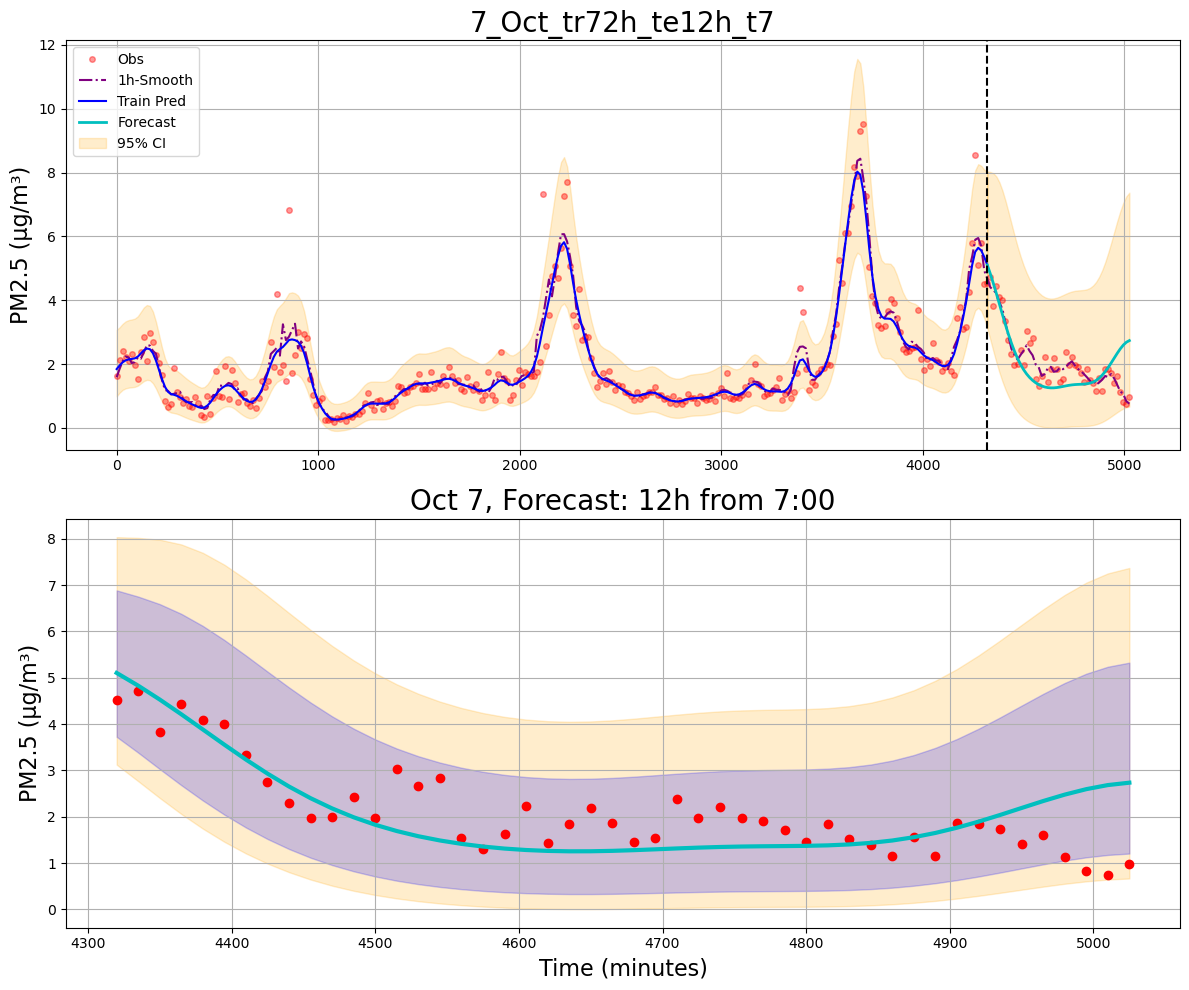

        Metric True Values Smoothed (sld1)
0          MSE       0.541           0.445
1   RMSE Train       0.589           0.161
2    RMSE Test       0.736           0.667
3        RMSLE       0.262           0.245
4          NMB      -0.020          -0.021
5         MAPE      35.588          34.038
6          IOA       0.856           0.876
7           R²       0.429           0.475
8         FAC2       0.917           0.917
9           FB      -0.020          -0.021
10  RMSE Ratio       1.250           4.130
✅ Saved: /Users/rachadawand/OneDrive - Newcastle University/Thesis/2018/Windspeed2018/G/Coding/m32+periodic/Clean Code/gp_results_update/plot_7_Oct_tr72h_te12h_t7_full.png


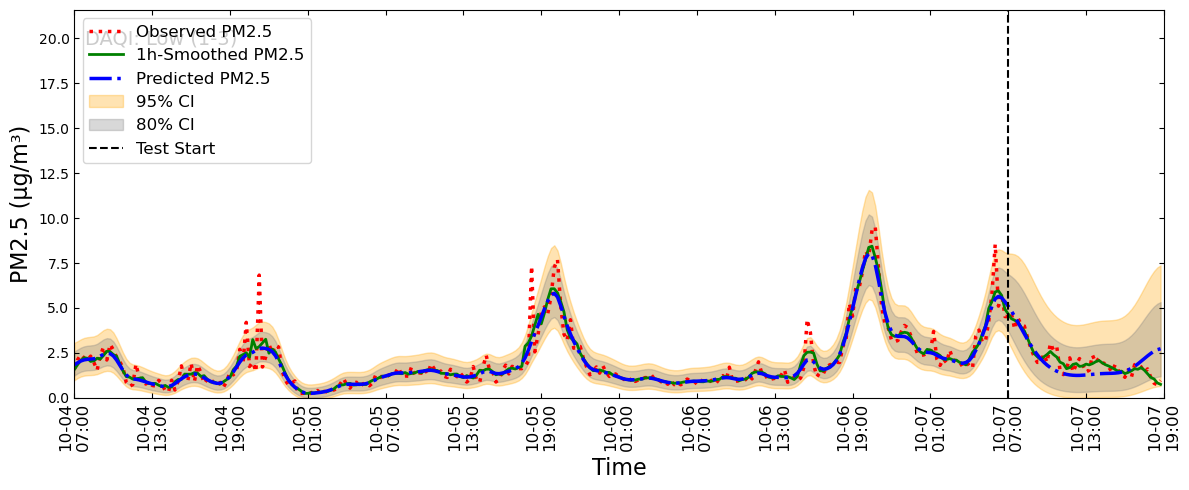

✅ Saved: /Users/rachadawand/OneDrive - Newcastle University/Thesis/2018/Windspeed2018/G/Coding/m32+periodic/Clean Code/gp_results_update/plot_7_Oct_tr72h_te12h_t7_test.png


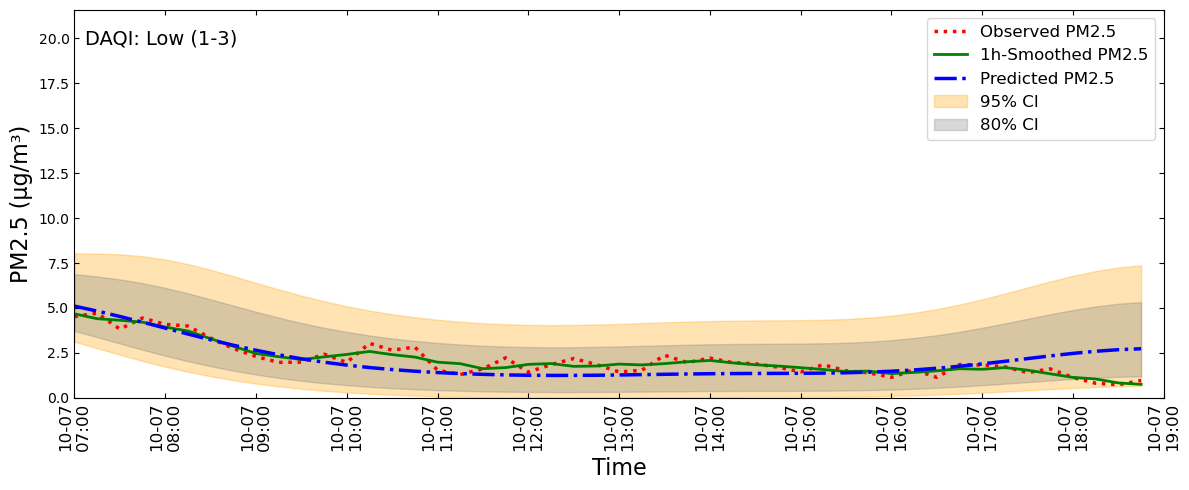

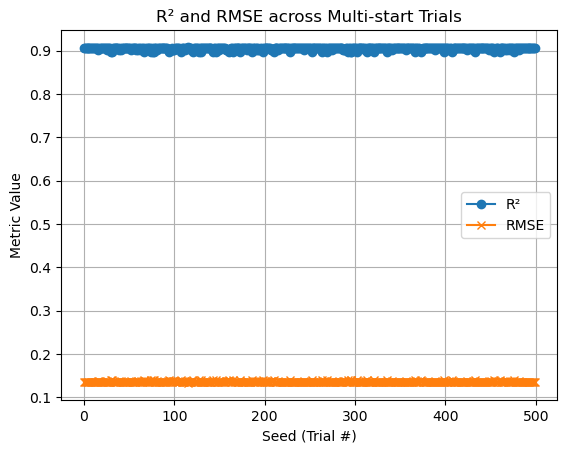

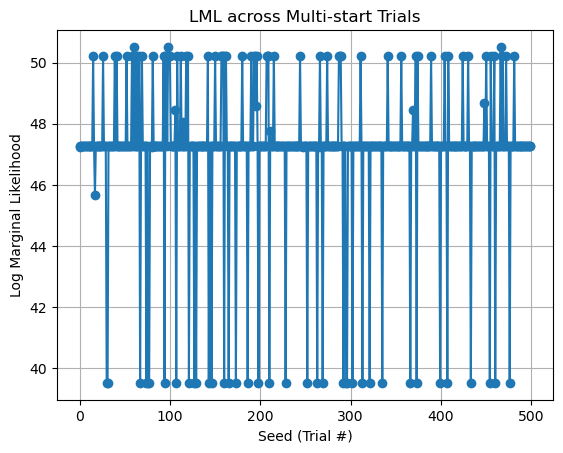


✅ All results saved successfully!
📁 Output directory: gp_results_update/Oct
✔️ Valid days: 1
⚠️ Skipped days: 0


In [ ]:
# =========================================================
# Batch Gaussian Process Forecasting for Selected Dates
# =========================================================

"""
Batch Gaussian Process Forecasting Pipeline

Description
-----------
This script runs Gaussian Process (GP) models for selected day(s),
generates forecasts, evaluates performance, and saves results.

Workflow
--------
1. Define target dates and output directory
2. Configure training and forecasting durations
3. Loop through selected days
4. Validate data availability
5. Train GP model using process_gp_model()
6. Store predictions and evaluation metrics
7. Save outputs (.npz and .pkl)

Assumptions
-----------
- Data resolution: 15 minutes (96 samples/day)
- Forecast start time: configurable (default 07:00)
- Uses log transformation ("ln") for stability

Outputs
-------
- Predictions (mean + variance)
- Evaluation metrics
- Kernel parameters
- Saved in:
    gp_results_update/<Month>/
"""

# =========================================================
# 1. Configuration
# =========================================================

import numpy as np              # numerical computations (arrays, math)
import pandas as pd             # data handling (Series/DataFrame)
import pickle                   # save Python objects (parameters/models)
import os                       # file system operations
from calendar import monthrange # get number of days in month

# --- Target configuration ---
target_month = 10   # January  # target month for experiment (1=Jan, 4=Apr, 7=Jul, 10=Oct)
day = 7           # specific day to run GP model
dates = [(day, target_month)]  # list of (day, month) pairs for batch processing

drive = "gp_results_update/Oct"  # output folder name for this experiment

# --- Create output directories ---
os.makedirs("gp_results_update", exist_ok=True)  # ensure base directory exists
output_path = f"{drive}"                  # full output path
os.makedirs(output_path, exist_ok=True)          # create output directory if not exists

# --- Training / Forecast setup ---
train_duration = [int(3 * 24 * 60 / 15)]   # training window (3 days = 288 steps at 15-min resolution)
test_duration  = [int(12 * 60 / 15)]       # forecast horizon (12 hours = 48 steps)
t_duration     = [7]                       # forecast start time (hour of day)

# --- Time setup ---
year = 2018                                # dataset year
last_day = monthrange(year, target_month)[1]  # number of days in selected month


# =========================================================
# 2. Preallocate Storage
# =========================================================

num_days = len(dates)  # total number of days to process

fmean_train_2period_set_all = np.full((num_days, train_duration[0]), np.nan)  # store GP mean (train)
fvar_train_2period_set_all  = np.full((num_days, train_duration[0]), np.nan)  # store GP variance (train)
fmean_test_2period_set_all  = np.full((num_days, test_duration[0]), np.nan)   # store GP mean (test)
fvar_test_2period_set_all   = np.full((num_days, test_duration[0]), np.nan)   # store GP variance (test)

val_true_2period_set_all = np.full((num_days, 11), np.nan)  # validation true values (forecast window)
val_sld1_2period_set_all = np.full((num_days, 11), np.nan)  # validation smoothed values

# --- Metadata storage ---
skipped_days = []  # list of days skipped due to errors or insufficient data
valid_days = []    # list of successfully processed days

init_params_2period_set_all = []  # initial kernel parameters
opt_params_2period_set_all  = []  # optimized kernel parameters
best_model_2period_set_all  = []  # trained GP models


# =========================================================
# 3. Main Processing Loop
# =========================================================

for day_idx, (day, month) in enumerate(dates):  # iterate through selected dates

    # --- Convert calendar day → dataset index ---
    if month == 1:
        k = day - 1                      # January index offset
    elif month == 4:
        k = 90 + day - 1                 # April offset (after Jan–Mar)
    elif month == 7:
        k = 181 + day - 1                # July offset
    elif month == 10:
        k = 273 + day - 1                # October offset
    else:
        skipped_days.append((day, f"Month {month} not supported"))  # unsupported month
        continue

    start_idx = k * 96   # convert day index → data index (96 samples/day)
    end_idx   = start_idx + train_duration[0]  # end index of training window

    # --- Data validation ---
    if end_idx > len(PM25_data):
        skipped_days.append((day, "Index exceeds data length"))  # not enough data
        continue

    train_slice = PM25_data[start_idx:end_idx]  # extract training data

    if train_slice.isna().all() or train_slice.count() < 0.3 * train_duration[0]:
        skipped_days.append((day, "Insufficient data"))  # too many missing values
        continue

    try:
        print(f"\n📅 Running GP model for {day:02d}-{month:02d}...")  # log current run

        # =========================================================
        # 4. Run GP Model
        # =========================================================
        (
            fmean_train_, fvar_train_,      # GP predictions (train)
            fmean_test_, fvar_test_,        # GP predictions (test)
            val_true_, val_sld1_,           # validation data
            best_metrics, best_lml,         # evaluation metrics
            best_init_params, best_opt_params, # kernel parameters
            best_model                     # trained GP model object
        ) = process_gp_model(
            train_duration=train_duration,  # training window
            test_duration=test_duration,    # forecast horizon
            t_duration=t_duration,          # forecast start time
            start_dates=[k],                # dataset start index
            end_dates=[k + 1],              # dataset end index
            month=month,                   # current month
            PM25_data=PM25_data,           # raw PM2.5 data
            Smooth_PM25=Smooth_PM25,       # smoothed PM2.5 data
            num_int=500,                  # number of multi-start initializations (⚠️ heavy)
            opt_inter=2000,                # optimizer iterations
            method="ln",                   # transformation method (log)
            mean_opt="zero",               # GP mean function
            set_opt=True,                 # whether to optimize hyperparameters
            set_prior=False,               # whether to use prior
            fig_name="gp_run_custom_dates",# figure naming
            kernel_model="M32+P_sub+P_daily" # kernel structure
        )

        # =========================================================
        # 5. Store Results
        # =========================================================
        fmean_train_2period_set_all[day_idx, :] = ensure_numpy_1d(fmean_train_)[:train_duration[0]]  # save train mean
        fvar_train_2period_set_all[day_idx, :]  = ensure_numpy_1d(fvar_train_)[:train_duration[0]]   # save train variance

        fmean_test_2period_set_all[day_idx, :] = ensure_numpy_1d(fmean_test_)[:test_duration[0]]  # save test mean
        fvar_test_2period_set_all[day_idx, :]  = ensure_numpy_1d(fvar_test_)[:test_duration[0]]   # save test variance

        val_true_2period_set_all[day_idx, :] = val_true_   # save validation true values
        val_sld1_2period_set_all[day_idx, :] = val_sld1_   # save validation smoothed values

        init_params_2period_set_all.append(best_init_params)  # store initial kernel params
        opt_params_2period_set_all.append(best_opt_params)    # store optimized kernel params
        best_model_2period_set_all.append(best_model)         # store trained model

        valid_days.append((day, month))  # mark as successful

    except Exception as e:
        print(f"❌ Failed on {day:02d}-{month:02d}: {e}")  # print error
        skipped_days.append(((day, month), str(e)))       # log failed case
        continue


# =========================================================
# 6. Save Results
# =========================================================

kernel_name = f"M32P_subP_daily_{year}-{target_month:02d}"  # naming for output files

np.savez_compressed(
    f"{output_path}/custom_gp_outputs_{kernel_name}.npz",  # output file path
    fmean_train=fmean_train_2period_set_all,               # save train mean
    fvar_train=fvar_train_2period_set_all,                 # save train variance
    fmean_test=fmean_test_2period_set_all,                 # save test mean
    fvar_test=fvar_test_2period_set_all,                   # save test variance
    val_true=val_true_2period_set_all,                     # save validation true
    val_sld1=val_sld1_2period_set_all                      # save validation smoothed
)

with open(f"{output_path}/custom_gp_parameters_{kernel_name}.pkl", "wb") as f:  # open file for writing
    pickle.dump({
        "valid_days": valid_days,              # successful runs
        "init_params": init_params_2period_set_all,  # initial parameters
        "opt_params": opt_params_2period_set_all,    # optimized parameters
        "skipped_days": skipped_days          # failed/skipped runs
    }, f)


# =========================================================
# 7. Summary
# =========================================================

print("\n✅ All results saved successfully!")  # completion message
print(f"📁 Output directory: {output_path}")  # show output path
print(f"✔️ Valid days: {len(valid_days)}")    # number of successful runs
print(f"⚠️ Skipped days: {len(skipped_days)}")  # number of skipped runs